# Visualization Notebook
Reads saved CSVs from pipeline scripts 02, 08, 09.

In [1]:
# CELL 1: Setup

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.linalg import orthogonal_procrustes

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE = Path(processed_dir)
SEL_DIR = BASE / 'group_results' / 'selectivity'
LIU_DIR = BASE / 'group_results' / 'liu_distinctiveness'
GEO_DIR = BASE / 'group_results' / 'geometry'
FIG_DIR = BASE / 'group_results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

COPE_SET = 'differential'  # Change as needed

CTRL_L = '#a0a0a0'
CTRL_R = '#505050'
OTC_L = '#7398af'
OTC_R = '#ee7183'
NONOT = '#FF9800'
CAT_COLORS = {'face': OTC_R, 'word': '#9C27B0', 'house': OTC_L, 'object': '#4CAF50'}
CAT_MARKERS = {'face': 'o', 'word': 's', 'house': '^', 'object': 'D'}
CATEGORIES = ['face', 'house', 'object', 'word']
BILATERAL = ['object', 'house']
REORG = {'left': 'word', 'right': 'face'}

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

RNG = np.random.default_rng(42)


def short_name(code):
    return code.replace('OTC', '').replace('nonOTC', 'n').replace('control', 'c')

print(f'Setup complete. COPE_SET={COPE_SET}')

Setup complete. COPE_SET=differential


In [2]:
# %%
# FIGURE 1: SELECTIVITY — Sum Selectivity Norm (Ayzenberg)

def fig_selectivity(metric='sum_selec_norm'):
    """Violin + jitter: selectivity per category, Controls L/R vs OTC-left/right, patients labeled."""
    sel_file = SEL_DIR / 'selectivity_summary.csv'
    if not sel_file.exists():
        print(f'  SKIP: {sel_file} not found')
        return

    df = pd.read_csv(sel_file)

    df['ses_int'] = df['ses'].astype(int)
    first = df.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'fs'})
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False) # use True for shared y-axis across categories

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        vd, vp, vc = [], [], []

        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'left')][metric].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'right')][metric].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                      color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(len(vals)),
                       color='black', marker='s', markersize=6,
                       markerfacecolor=color, markeredgecolor='black',
                       markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)
        
        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd[metric].values

            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)

            for _, row in sd.iterrows():
                jit = RNG.uniform(-0.18, 0.18)
                sub_short = row['sub'].replace('sub-', '')
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f'{sub_short}{star}', (pos + jit, row[metric]),
                           fontsize=7, fontweight='bold', ha='center', va='center',
                           bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                    edgecolor=color, alpha=0.85, linewidth=0.8),
                           zorder=4)

            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(max(len(vals), 1)),
                           color='black', marker='s', markersize=6,
                           markerfacecolor=color, markeredgecolor='black',
                           markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)             

        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i])
                body.set_alpha(0.3)
                body.set_edgecolor(vc[i])
                body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            label_map = {'sum_selec_norm': 'Summed Selectivity\n(normalized)',
                        'mean_act': 'Mean Activation (z)'}
            ax.set_ylabel(label_map.get(metric, metric))

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L, alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R, alpha=0.5, label='OTC Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    title_map = {'sum_selec_norm': 'Summed Selectivity (Normalized)',
                 'mean_act': 'Mean Activation'}
    plt.suptitle(title_map.get(metric, metric), fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_selectivity_{metric}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_selectivity_{metric}.png')


def fig_selectivity_free(metric='sum_selec_norm'):
    """Same but independent y-scales per category."""
    sel_file = SEL_DIR / 'selectivity_summary.csv'
    if not sel_file.exists():
        print(f'  SKIP: {sel_file} not found')
        return

    df = pd.read_csv(sel_file)

    df['ses_int'] = df['ses'].astype(int)
    first = df.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'fs'})
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        vd, vp, vc = [], [], []

        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'left')][metric].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'right')][metric].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                      color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(len(vals)),
                       color='black', marker='s', markersize=6,
                       markerfacecolor=color, markeredgecolor='black',
                       markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd[metric].values

            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)

            for _, row in sd.iterrows():
                jit = RNG.uniform(-0.12, 0.12)
                sub_short = row['sub'].replace('sub-', '')
                star = '*' if REORG.get(side) == cat else ''
                ax.scatter(pos + jit, row[metric],
                          color=color, s=40, zorder=3, edgecolors='black',
                          linewidth=0.5, alpha=0.8)
                ax.annotate(f'{sub_short}{star}', (pos + jit, row[metric]),
                           fontsize=7, fontweight='bold', ha='center', va='bottom',
                           xytext=(0, 5), textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                    edgecolor=color, alpha=0.85, linewidth=0.8))

            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(max(len(vals), 1)),
                           color='black', marker='s', markersize=6,
                           markerfacecolor=color, markeredgecolor='black',
                           markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i])
                body.set_alpha(0.3)
                body.set_edgecolor(vc[i])
                body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        ax.set_ylabel('Summed Selectivity\n(normalized)' if metric == 'sum_selec_norm' else 'Mean Activation (z)')

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L, alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R, alpha=0.5, label='OTC Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    title_map = {'sum_selec_norm': 'Summed Selectivity (Independent Scales)',
                 'mean_act': 'Mean Activation (Independent Scales)'}
    plt.suptitle(title_map.get(metric, metric), fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_selectivity_{metric}_free.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_selectivity_{metric}_free.png')

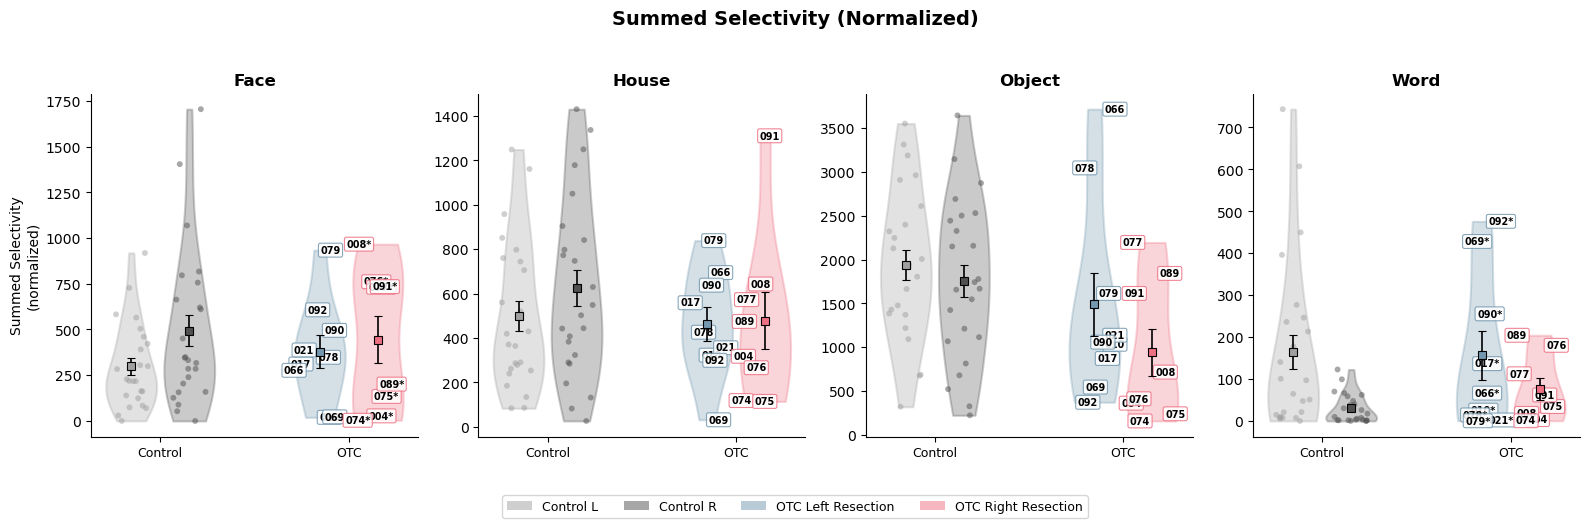

  Saved: fig_selectivity_sum_selec_norm.png


In [3]:
# Run: Summed Selectivity
fig_selectivity('sum_selec_norm')

In [4]:
def fig_liu_distinctiveness(cope_set='differential'):
    """Violin + jitter: Liu distinctiveness per category, Controls L/R vs OTC-left/right, patients labeled."""
    liu_file = LIU_DIR / f'liu_distinctiveness_{cope_set}.csv'
    if not liu_file.exists():
        print(f'  SKIP: {liu_file} not found')
        return

    df = pd.read_csv(liu_file)

    # First session per subject
    first = df.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    df = df.merge(first, on='subject_id')
    cross = df[df['session'] == df['fs']]

    ctrl = cross[cross['status'] == 'control'].copy()
    otc  = cross[(cross['group'] == 'OTC') & (cross['hemi_label'] == 'intact')].copy()

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)  # use True for shared y-axis

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        vd, vp, vc = [], [], []

        # ── Controls: split left / right hemisphere ──────────────────────────
        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'left')]['liu_distinctiveness'].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'right')]['liu_distinctiveness'].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── OTC patients: labeled badges ──────────────────────────────────────
        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd['liu_distinctiveness'].values

            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)

            for _, row in sd.iterrows():
                jit = RNG.uniform(-0.18, 0.18)
                lbl  = short_name(row['subject'])
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f'{lbl}{star}', (pos + jit, row['liu_distinctiveness']),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=color, alpha=0.85, linewidth=0.8),
                            zorder=4)

            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                            color='black', marker='s', markersize=6,
                            markerfacecolor=color, markeredgecolor='black',
                            markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── Violins ───────────────────────────────────────────────────────────
        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i])
                body.set_alpha(0.3)
                body.set_edgecolor(vc[i])
                body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f'Liu Distinctiveness ({cope_set})', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_liu_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_liu_{cope_set}.png')

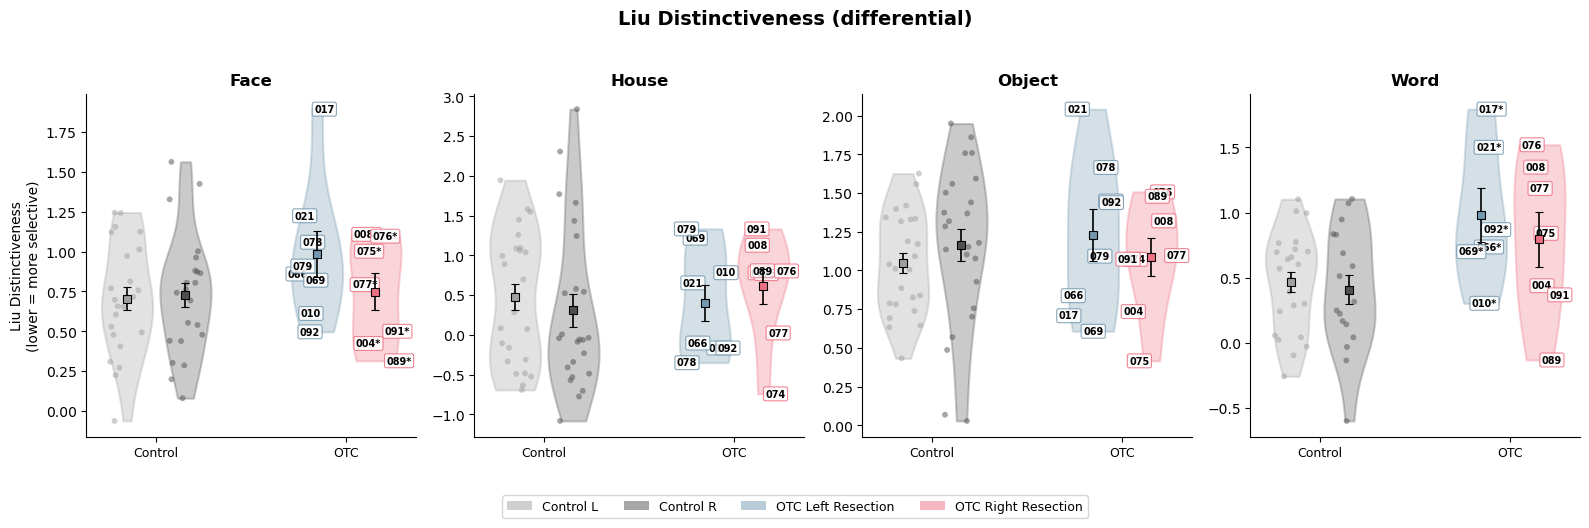

  Saved: fig_liu_differential.png


In [5]:
# Run: Liu Distinctiveness
fig_liu_distinctiveness(COPE_SET)

In [6]:
# FIGURE 3: PAIRWISE HEATMAPS — Controls vs OTC-left vs OTC-right
def fig_pairwise_heatmaps(cope_set='differential', roi_type='unilateral', alpha=0.05):
    """3-panel heatmap of pairwise Fisher-z pattern correlations (intact hemi only for OTC).
    Significance vs controls via Mann-Whitney U, BH-FDR corrected per OTC panel."""
    from scipy import stats

    pair_file = LIU_DIR / f'pairwise_correlations_{cope_set}.csv'
    if not pair_file.exists():
        print(f'  SKIP: {pair_file} not found')
        return

    df = pd.read_csv(pair_file)

    # First session per subject
    first = df.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    df = df.merge(first, on='subject_id')
    df = df[df['session'] == df['fs']]

    # Assign plot group; restrict OTC to intact hemisphere only
    df['plot_group'] = df.apply(
        lambda r: f"OTC-{r['surgery_side']}" if r['group'] == 'OTC' else r['group'], axis=1)
    uni = df[df['cat_type'] == roi_type].copy()
    uni = uni[~((uni['group'] == 'OTC') & (uni['hemi_label'] != 'intact'))]

    cats = ['face', 'word', 'house', 'object']

    def get_vals(subset, ci, cj):
        for pair_str in [f'{ci}-{cj}', f'{cj}-{ci}']:
            v = subset[subset['pair'] == pair_str]['fisher_r'].values
            if len(v) > 0:
                return v
        return np.array([])

    def bh_fdr(pvals, alpha=0.05):
        """Benjamini-Hochberg FDR correction. Returns boolean array of rejected nulls."""
        pvals = np.asarray(pvals)
        n = len(pvals)
        order = np.argsort(pvals)
        ranked = np.empty(n, dtype=float)
        ranked[order] = np.arange(1, n + 1)
        threshold = (ranked / n) * alpha
        # All hypotheses up to the largest k where p <= threshold are rejected
        below = pvals <= threshold
        if not below.any():
            return np.zeros(n, dtype=bool)
        max_k = np.where(below)[0][np.argmax(np.where(below)[0])]  # largest index in sorted order
        cutoff = pvals[order[max_k]]
        return pvals <= cutoff

    ctrl_data = uni[uni['plot_group'] == 'control']

    # ── Layout: 3 panels + manual colorbar axis ──────────────────────────────
    fig = plt.figure(figsize=(17, 5))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.06], wspace=0.25)
    axes = [fig.add_subplot(gs[i]) for i in range(3)]
    cbar_ax = fig.add_subplot(gs[3])

    groups = [
        ('control',   'Controls'),
        ('OTC-left',  'Left Resection\n(Word* → Right Hemi)'),
        ('OTC-right', 'Right Resection\n(Face* → Left Hemi)'),
    ]

    im_ref = None
    for ax_idx, (grp, title) in enumerate(groups):
        ax = axes[ax_idx]
        gd = uni[uni['plot_group'] == grp]

        mat = np.full((4, 4), np.nan)
        raw_p = {}  # (i,j) → p-value, for off-diagonal OTC cells only

        # Collect means and raw p-values
        for i, ci in enumerate(cats):
            for j, cj in enumerate(cats):
                if i == j:
                    continue
                vals = get_vals(gd, ci, cj)
                if len(vals) == 0:
                    continue
                mat[i, j] = vals.mean()
                if grp != 'control':
                    ctrl_vals = get_vals(ctrl_data, ci, cj)
                    if len(ctrl_vals) >= 2 and len(vals) >= 2:
                        _, p = stats.mannwhitneyu(vals, ctrl_vals, alternative='two-sided')
                        raw_p[(i, j)] = p

        # BH-FDR across all 12 off-diagonal cells for this OTC panel
        sig = np.full((4, 4), False)
        if raw_p:
            keys = list(raw_p.keys())
            pvals = np.array([raw_p[k] for k in keys])
            rejected = bh_fdr(pvals, alpha=alpha)
            for k, rej in zip(keys, rejected):
                sig[k] = rej

        im = ax.imshow(mat, cmap='RdYlBu_r', vmin=0, vmax=1.5, aspect='equal')
        if im_ref is None:
            im_ref = im

        ax.set_xticks(range(4))
        ax.set_xticklabels([c.title() for c in cats], fontsize=10)
        ax.set_yticks(range(4))
        ax.set_yticklabels([c.title() for c in cats] if ax_idx == 0 else [], fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')

        for i in range(4):
            for j in range(4):
                if np.isnan(mat[i, j]):
                    continue
                txt_color = 'white' if mat[i, j] > 1.0 else 'black'
                label_txt = f'{mat[i,j]:.2f}{"*" if sig[i,j] else ""}'
                ax.text(j, i, label_txt, ha='center', va='center',
                        fontsize=9, color=txt_color, fontweight='bold')
                if sig[i, j]:
                    rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                         fill=False, edgecolor='black',
                                         linewidth=2.5, zorder=5)
                    ax.add_patch(rect)

    fig.colorbar(im_ref, cax=cbar_ax,
                 label='Fisher-z (voxelwise pattern similarity)\nhigher = less distinct')

    fig.text(0.5, -0.03,
             f'* p < {alpha}, BH-FDR corrected (12 pairs per panel, Mann–Whitney U two-sided); '
             f'OTC: intact hemisphere only',
             ha='center', fontsize=9, style='italic')

    plt.suptitle(f'Pairwise Pattern Similarity — {roi_type.title()} ROIs ({cope_set})',
                 fontsize=14, fontweight='bold')
    plt.savefig(str(FIG_DIR / f'fig_heatmap_{roi_type}_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_heatmap_{roi_type}_{cope_set}.png')

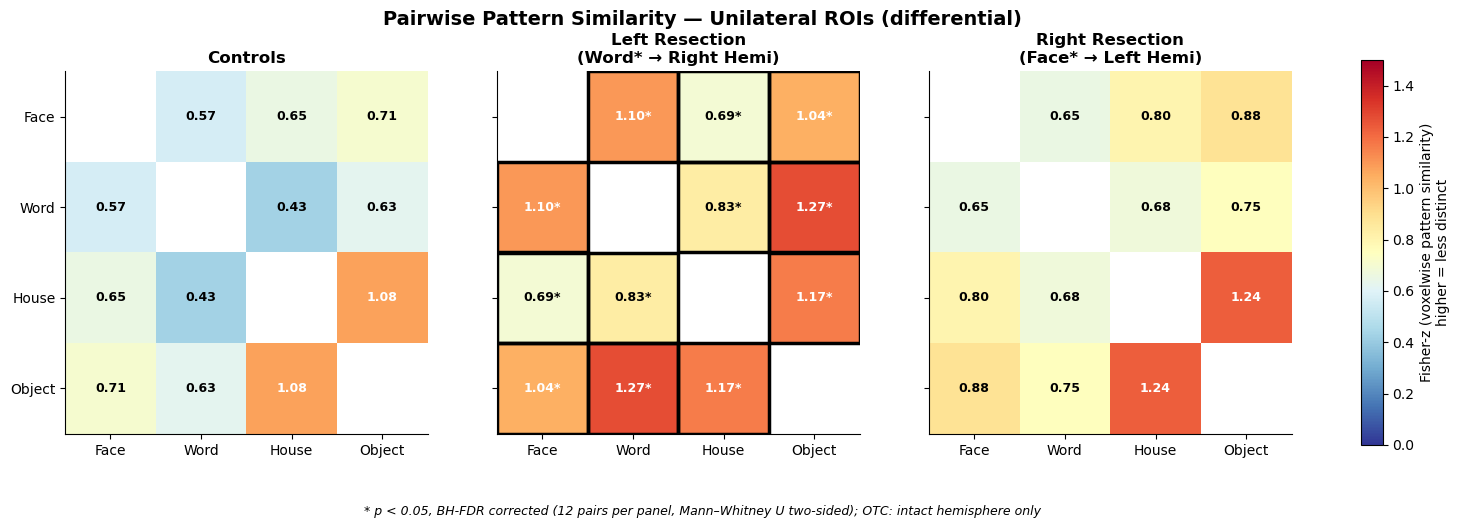

  Saved: fig_heatmap_unilateral_differential.png


In [7]:
# Run: Pairwise Heatmaps
fig_pairwise_heatmaps(COPE_SET, 'unilateral')

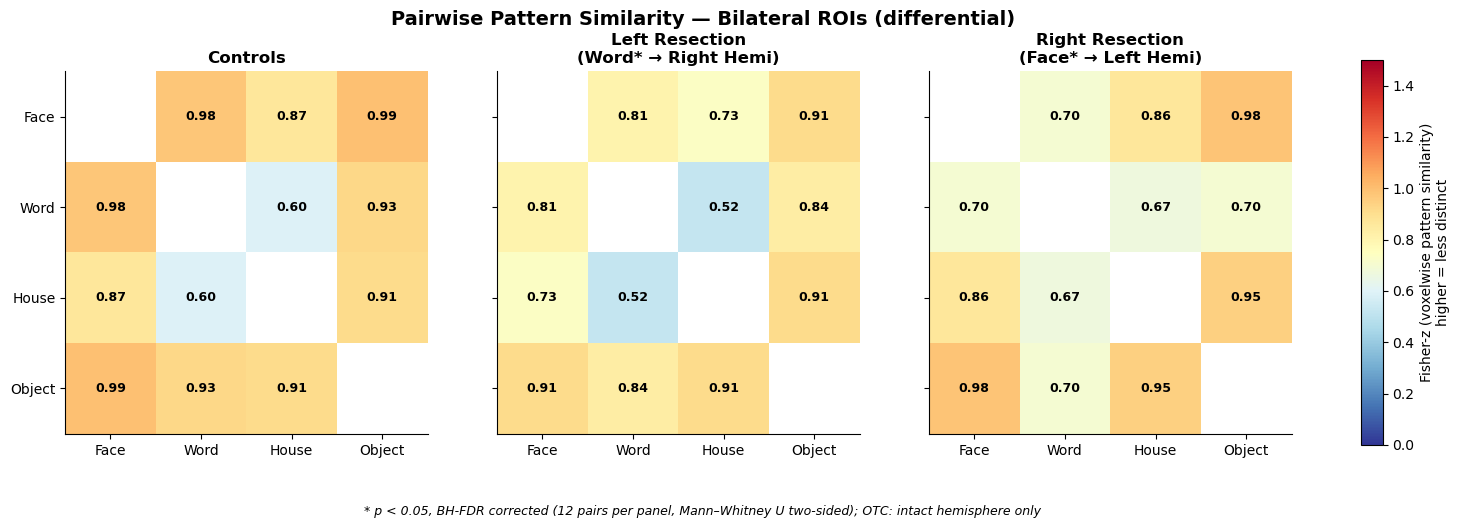

  Saved: fig_heatmap_bilateral_differential.png


In [8]:
fig_pairwise_heatmaps(COPE_SET, 'bilateral')

In [9]:
def fig_geometry(cope_set='differential'):
    """Violin + jitter: geometry preservation per category, Controls L/R vs OTC-left/right, patients labeled."""
    geo_file = GEO_DIR / f'geometry_{cope_set}.csv'
    if not geo_file.exists():
        print(f'  SKIP: {geo_file} not found')
        return

    df = pd.read_csv(geo_file)

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)  # use True for shared y-axis

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        vd, vp, vc = [], [], []

        # ── Controls: split left / right hemisphere ───────────────────────────
        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'left')]['geometry_preservation'].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'right')]['geometry_preservation'].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── OTC patients: labeled badges ──────────────────────────────────────
        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd['geometry_preservation'].values

            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)

            for _, row in sd.iterrows():
                jit = RNG.uniform(-0.18, 0.18)
                lbl  = short_name(row['subject'])
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f'{lbl}{star}', (pos + jit, row['geometry_preservation']),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=color, alpha=0.85, linewidth=0.8),
                            zorder=4)

            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                            color='black', marker='s', markersize=6,
                            markerfacecolor=color, markeredgecolor='black',
                            markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── Violins ───────────────────────────────────────────────────────────
        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i])
                body.set_alpha(0.3)
                body.set_edgecolor(vc[i])
                body.set_linewidth(1.5)

        ax.axhline(0, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Geometry Preservation (r)\n(higher = more stable)')

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f'Geometry Preservation ({cope_set})', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_geometry_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_geometry_{cope_set}.png')

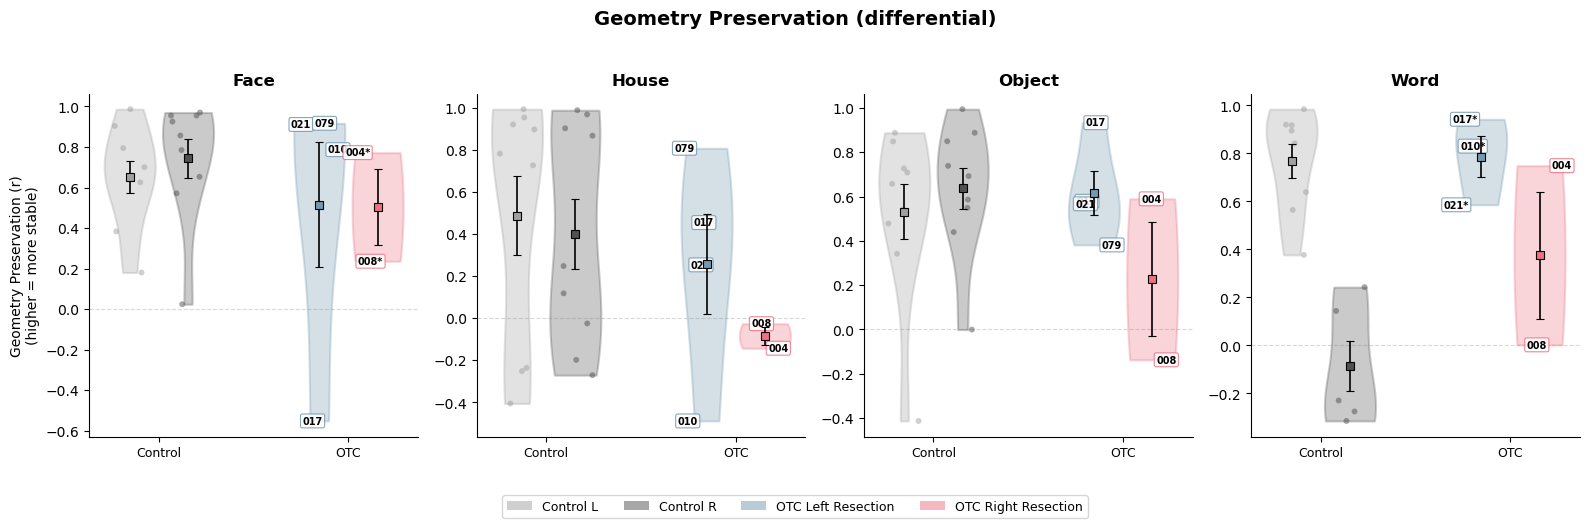

  Saved: fig_geometry_differential.png


In [10]:
# Run: Geometry Preservation
fig_geometry(COPE_SET)

In [11]:
# FIGURE 5: SPATIAL RELOCATION — Per category, patients labeled
def fig_spatial(cope_set='differential'):
    """Violin + jitter: spatial relocation per category, Controls L/R vs OTC-left/right, patients labeled."""
    sp_file = GEO_DIR / f'spatial_{cope_set}.csv'
    if not sp_file.exists():
        print(f'  SKIP: {sp_file} not found')
        return

    df = pd.read_csv(sp_file)

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)  # use True for shared y-axis

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        vd, vp, vc = [], [], []

        # ── Controls: split left / right hemisphere ───────────────────────────
        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'left')]['relocation_mm'].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'right')]['relocation_mm'].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── OTC patients: labeled badges ──────────────────────────────────────
        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd['relocation_mm'].values

            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)

            for _, row in sd.iterrows():
                jit = RNG.uniform(-0.18, 0.18)
                lbl  = short_name(row['subject'])
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f'{lbl}{star}', (pos + jit, row['relocation_mm']),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=color, alpha=0.85, linewidth=0.8),
                            zorder=4)

            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                            color='black', marker='s', markersize=6,
                            markerfacecolor=color, markeredgecolor='black',
                            markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── Violins ───────────────────────────────────────────────────────────
        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i])
                body.set_alpha(0.3)
                body.set_edgecolor(vc[i])
                body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Centroid Displacement (mm)')

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f'Spatial Relocation ({cope_set})', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_spatial_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_spatial_{cope_set}.png')

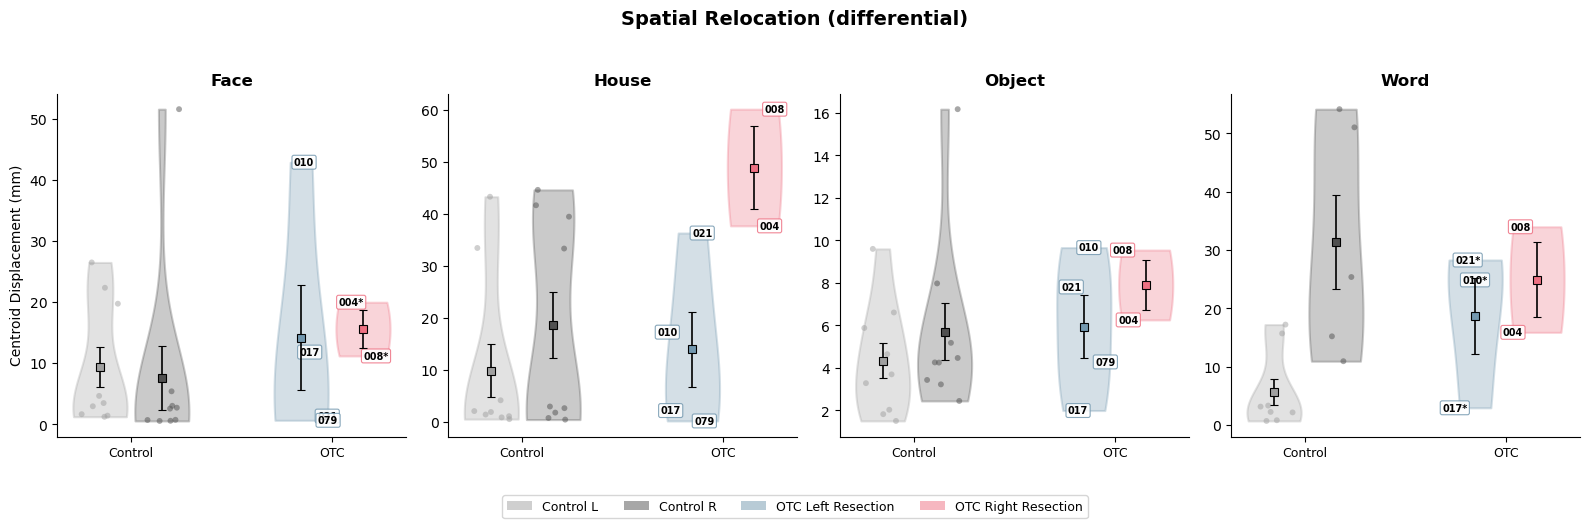

  Saved: fig_spatial_differential.png


In [12]:
# Run: Spatial Relocation
fig_spatial(COPE_SET)

In [13]:
# FIGURE 6: MDS PLOTS — Per patient, shift per category

def fig_mds_patients(cope_set='differential'):
    """Per-patient MDS: T1 and T2 category embeddings overlaid."""
    mds_file = GEO_DIR / f'mds_{cope_set}.csv'
    geo_file = GEO_DIR / f'geometry_{cope_set}.csv'
    if not mds_file.exists():
        print(f'  SKIP: {mds_file} not found')
        return

    mds_df = pd.read_csv(mds_file)
    # MDS file has shift per measured category but not the actual coordinates
    # We need to recompute MDS from the geometry pipeline's RDMs
    # For now, use the shift values as a bar chart per patient

    otc = mds_df[mds_df['group'] == 'OTC']
    patients = sorted(otc['subject'].unique())
    n = len(patients)
    if n == 0:
        print('  No OTC patients with MDS data')
        return

    cols = min(n, 3)
    rows_n = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(5*cols, 4*rows_n), squeeze=False)

    for idx, patient in enumerate(patients):
        ax = axes[idx // cols][idx % cols]
        pd_data = otc[otc['subject'] == patient]
        side = pd_data['surgery_side'].iloc[0]

        cats_present = []
        shifts = []
        colors = []
        for cat in CATEGORIES:
            cd = pd_data[pd_data['measured_category'] == cat]
            if len(cd) > 0:
                val = cd['mds_shift'].mean()
                cats_present.append(cat)
                shifts.append(val)
                colors.append(CAT_COLORS[cat])

        x = np.arange(len(cats_present))
        bars = ax.bar(x, shifts, color=colors, edgecolor='black', linewidth=0.5, alpha=0.8)

        # Asterisk for reorganized
        for i, cat in enumerate(cats_present):
            if REORG.get(side) == cat:
                ax.text(i, shifts[i] + 0.005, '*', ha='center', fontsize=14, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels([c.title() for c in cats_present], fontsize=9)
        short = short_name(patient)
        ax.set_title(f'{short} ({side} resection)', fontsize=11, fontweight='bold')
        ax.set_ylabel('MDS Shift', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for idx in range(n, rows_n * cols):
        axes[idx // cols][idx % cols].set_visible(False)

    plt.suptitle(f'MDS Embedding Shift Per Category ({cope_set})',
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_mds_patients_{cope_set}.png'),
               dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_mds_patients_{cope_set}.png')



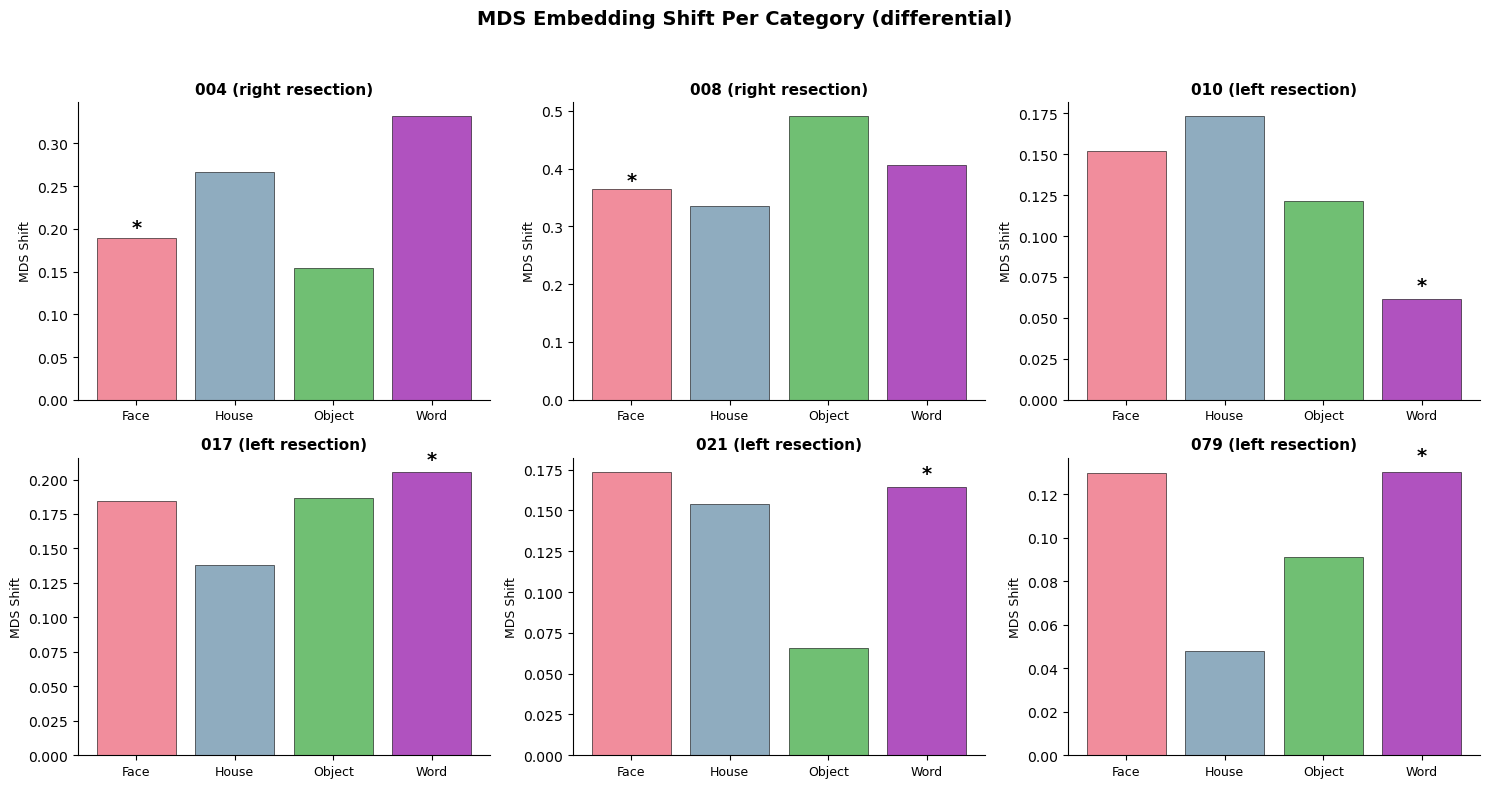

  Saved: fig_mds_patients_differential.png


In [14]:
fig_mds_patients(COPE_SET)

In [15]:
# FIGURE 7: PATIENT PROFILES — Relocation vs Geometry scatter
# ══════════════════════════════════════════════════════════════════════════════

def fig_patient_profiles(cope_set='differential'):
    """Per-patient scatter: relocation vs geometry for each category."""
    sp_file = GEO_DIR / f'spatial_{cope_set}.csv'
    geo_file = GEO_DIR / f'geometry_{cope_set}.csv'
    if not sp_file.exists() or not geo_file.exists():
        print(f'  SKIP: files not found')
        return

    spatial = pd.read_csv(sp_file)
    geom = pd.read_csv(geo_file)

    merged = spatial.merge(geom,
                          on=['subject_id', 'hemi', 'category', 'group', 'cat_type',
                              'surgery_side', 'status', 'subject', 'cope_set'],
                          suffixes=('_sp', '_gm'))

    otc = merged[merged['group'] == 'OTC']
    patients = sorted(otc['subject'].unique())
    n = len(patients)
    if n == 0:
        return

    cols = min(n, 3)
    rows_n = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(5*cols, 4.5*rows_n), squeeze=False)

    for idx, patient in enumerate(patients):
        ax = axes[idx // cols][idx % cols]
        pd_data = otc[otc['subject'] == patient]
        side = pd_data['surgery_side'].iloc[0]

        for _, row in pd_data.iterrows():
            cat = row['category']
            star = '*' if REORG.get(side) == cat else ''
            ax.scatter(row['relocation_mm'], row['geometry_preservation'],
                      c=CAT_COLORS[cat], marker=CAT_MARKERS[cat],
                      s=120, edgecolors='black', linewidth=0.8, zorder=5)
            ax.annotate(f'{cat.title()}{star}',
                       (row['relocation_mm'], row['geometry_preservation']),
                       fontsize=8, ha='left', va='bottom',
                       xytext=(4, 4), textcoords='offset points')

        short = short_name(patient)
        ax.set_title(f'{short} ({side} resection)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Relocation (mm)', fontsize=9)
        ax.set_ylabel('Geometry Pres. (r)', fontsize=9)
        ax.set_ylim(-0.7, 1.1)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.3)

    for idx in range(n, rows_n * cols):
        axes[idx // cols][idx % cols].set_visible(False)

    handles = [Line2D([0], [0], marker=CAT_MARKERS[c], color=CAT_COLORS[c],
               linestyle='None', markersize=8, markeredgecolor='black',
               markeredgewidth=0.8, label=c.title()) for c in CATEGORIES]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10,
              frameon=True, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle(f'Individual OTC Profiles ({cope_set})', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig(str(FIG_DIR / f'fig_profiles_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_profiles_{cope_set}.png')

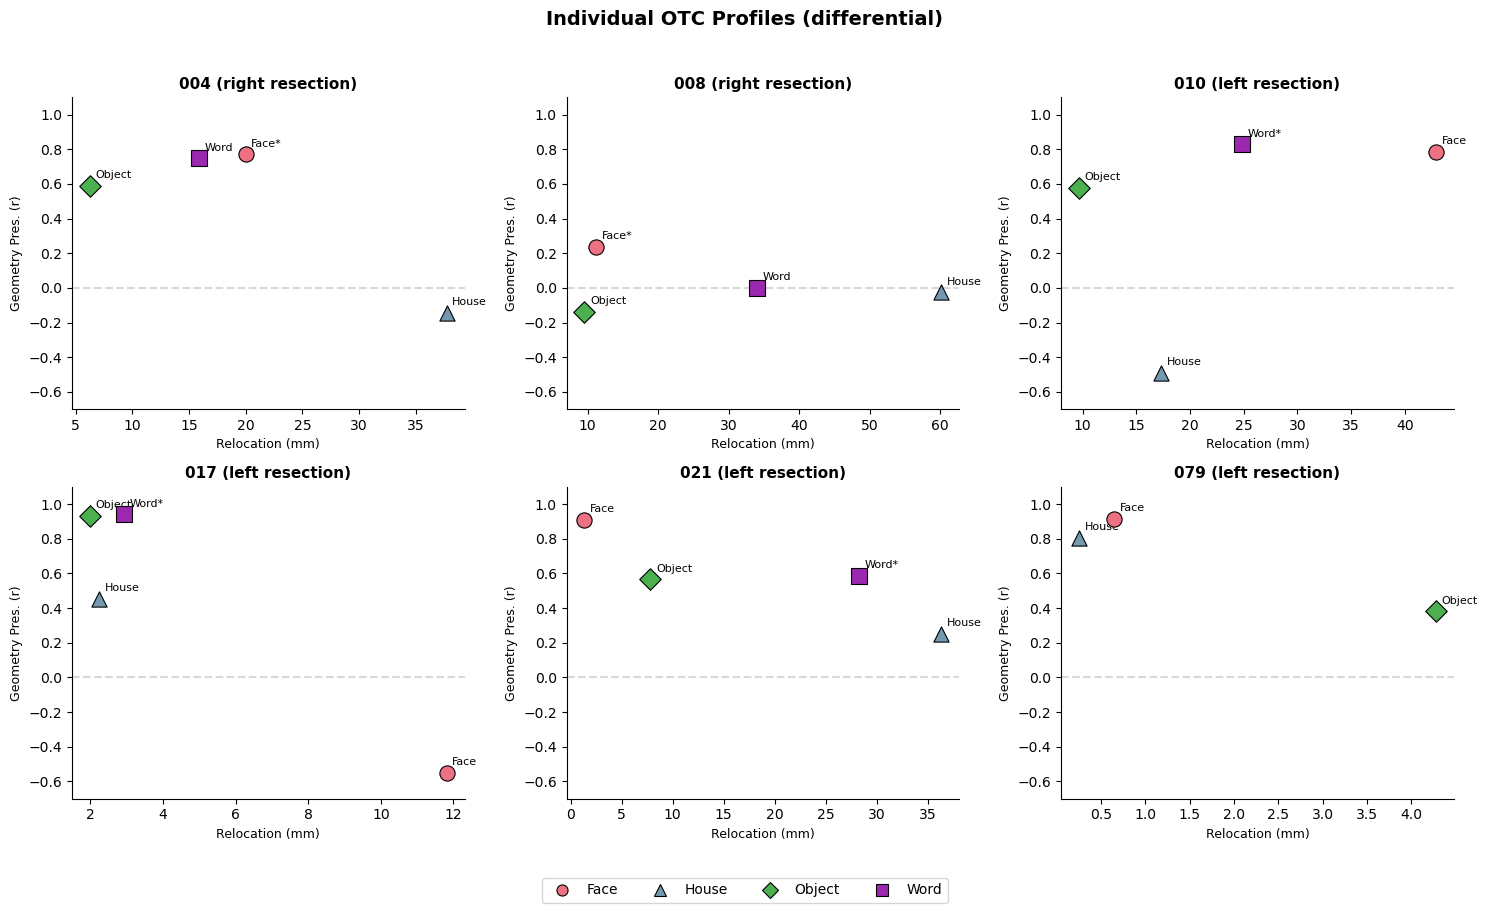

  Saved: fig_profiles_differential.png


In [16]:
fig_patient_profiles(COPE_SET)

In [17]:
# %%
# PUBLICATION RESULTS TABLE

from scipy.stats import mannwhitneyu, spearmanr
import statsmodels.formula.api as smf

def bootstrap_ci(data, n_boot=10000):
    rng = np.random.default_rng(42)
    means = [np.mean(rng.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    return np.mean(data), np.percentile(means, 2.5), np.percentile(means, 97.5)

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na-1)*np.std(a,ddof=1)**2 + (nb-1)*np.std(b,ddof=1)**2) / (na+nb-2))
    return (np.mean(a) - np.mean(b)) / pooled if pooled > 0 else np.nan

def rank_biserial(u, n1, n2):
    return 1 - (2*u) / (n1*n2)

cope = COPE_SET

# ══════════════════════════════════════════════════════════════════════════
# TABLE 1: Liu Distinctiveness — Cross-sectional OTC vs Controls
# ══════════════════════════════════════════════════════════════════════════

print("=" * 100)
print("TABLE 1: Liu Distinctiveness — Cross-Sectional (First Post-Surgery Session)")
print(f"Cope set: {cope}")
print("=" * 100)
print("Higher = less distinct (worse). * = reorganized category.")
print()

liu_file = LIU_DIR / f'liu_distinctiveness_{cope}.csv'
if liu_file.exists():
    liu = pd.read_csv(liu_file)
    first = liu.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    liu = liu.merge(first, on='subject_id')
    cross = liu[liu['session'] == liu['fs']]

    otc = cross[(cross['group'] == 'OTC') & (cross['hemi_label'] == 'intact')]
    ctrl = cross[cross['status'] == 'control']

    # OLS per category
    print(f"{'Category':<10} {'OTC mean':<12} {'OTC 95% CI':<22} {'Ctrl mean':<12} "
          f"{'Ctrl 95% CI':<22} {'β(OTC)':<10} {'SE':<8} {'p':<10} {'d':<8} {'R²'}")
    print("-" * 120)

    for cat in CATEGORIES:
        otc_vals = otc[otc['category'] == cat]['liu_distinctiveness'].values
        ctrl_vals = ctrl[ctrl['category'] == cat]['liu_distinctiveness'].values

        if len(otc_vals) < 2 or len(ctrl_vals) < 2:
            continue

        om, olo, ohi = bootstrap_ci(otc_vals)
        cm, clo, chi = bootstrap_ci(ctrl_vals)
        d = cohens_d(otc_vals, ctrl_vals)

        # OLS
        model_data = pd.DataFrame({
            'liu': np.concatenate([otc_vals, ctrl_vals]),
            'group': ['OTC']*len(otc_vals) + ['control']*len(ctrl_vals),
        })
        try:
            m = smf.ols('liu ~ C(group, Treatment("control"))', data=model_data).fit()
            gk = [k for k in m.params.index if 'OTC' in k][0]
            beta, se, p, r2 = m.params[gk], m.bse[gk], m.pvalues[gk], m.rsquared
        except:
            beta, se, p, r2 = np.nan, np.nan, np.nan, np.nan

        star = " " 
        print(f"{cat:<10} {om:<12.3f} [{olo:.3f}, {ohi:.3f}]    {cm:<12.3f} "
              f"[{clo:.3f}, {chi:.3f}]    {beta:<10.3f} {se:<8.3f} {p:<10.4f} {d:<8.2f} {r2:.3f}")

# ══════════════════════════════════════════════════════════════════════════
# TABLE 2: Liu Distinctiveness — By Surgery Side
# ══════════════════════════════════════════════════════════════════════════

print()
print("=" * 100)
print("TABLE 2: Liu Distinctiveness — OTC by Surgery Side vs Controls")
print("=" * 100)
print()

if liu_file.exists():
    otc['surgery_side_label'] = otc['subject_id'].map(
        lambda s: cross[cross['subject_id']==s]['surgery_side'].iloc[0] 
        if s in cross['subject_id'].values else 'na')

    print(f"{'Category':<10} {'Side':<8} {'OTC mean':<12} {'OTC 95% CI':<22} "
          f"{'Ctrl mean':<12} {'U':<10} {'p':<10} {'r_rb':<8} {'d'}")
    print("-" * 100)

    for cat in CATEGORIES:
        ctrl_vals = ctrl[ctrl['category'] == cat]['liu_distinctiveness'].values
        if len(ctrl_vals) < 2:
            continue
        cm, _, _ = bootstrap_ci(ctrl_vals)

        for side in ['left', 'right']:
            otc_side = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            ov = otc_side['liu_distinctiveness'].values
            if len(ov) < 2:
                continue

            om, olo, ohi = bootstrap_ci(ov)
            u, p = mannwhitneyu(ov, ctrl_vals, alternative='greater')
            rb = rank_biserial(u, len(ov), len(ctrl_vals))
            d = cohens_d(ov, ctrl_vals)
            star = "*" if REORG.get(side) == cat else " "

            print(f"{cat}{star:<9} {side:<8} {om:<12.3f} [{olo:.3f}, {ohi:.3f}]    "
                  f"{cm:<12.3f} {u:<10.0f} {p:<10.4f} {rb:<8.2f} {d:.2f}")

# ══════════════════════════════════════════════════════════════════════════
# TABLE 3: Pairwise Correlations — Unilateral ROIs
# ══════════════════════════════════════════════════════════════════════════

print()
print("=" * 100)
print("TABLE 3: Pairwise Category Correlations in Unilateral ROIs")
print("=" * 100)
print()

pair_file = LIU_DIR / f'pairwise_correlations_{cope}.csv'
if pair_file.exists():
    pdf = pd.read_csv(pair_file)
    first = pdf.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    pdf = pdf.merge(first, on='subject_id')
    pdf = pdf[pdf['session'] == pdf['fs']]
    pdf['plot_group'] = pdf.apply(
        lambda r: f"OTC-{r['surgery_side']}" if r['group'] == 'OTC' else r['group'], axis=1)
    uni = pdf[pdf['cat_type'] == 'unilateral']

    pairs = ['face-word', 'face-house', 'face-object', 'word-house', 'word-object', 'house-object']

    print(f"{'Pair':<15} {'Group':<12} {'Mean':<10} {'95% CI':<22} "
          f"{'vs Ctrl U':<12} {'p':<10} {'r_rb':<8} {'d'}")
    print("-" * 100)

    for pair in pairs:
        ctrl_p = uni[(uni['plot_group'] == 'control') & (uni['pair'] == pair)]['fisher_r']
        if len(ctrl_p) == 0:
            # Try reversed
            parts = pair.split('-')
            ctrl_p = uni[(uni['plot_group'] == 'control') & (uni['pair'] == f'{parts[1]}-{parts[0]}')]['fisher_r']

        ctrl_vals = ctrl_p.values
        if len(ctrl_vals) < 2:
            continue
        cm, clo, chi = bootstrap_ci(ctrl_vals)
        print(f"{pair:<15} {'control':<12} {cm:<10.3f} [{clo:.3f}, {chi:.3f}]")

        for grp in ['OTC-left', 'OTC-right']:
            gp = uni[(uni['plot_group'] == grp) & (uni['pair'] == pair)]['fisher_r']
            if len(gp) == 0:
                parts = pair.split('-')
                gp = uni[(uni['plot_group'] == grp) & (uni['pair'] == f'{parts[1]}-{parts[0]}')]['fisher_r']
            gv = gp.values
            if len(gv) < 2:
                continue

            gm, glo, ghi = bootstrap_ci(gv)
            u, p = mannwhitneyu(gv, ctrl_vals, alternative='greater')
            rb = rank_biserial(u, len(gv), len(ctrl_vals))
            d = cohens_d(gv, ctrl_vals)
            print(f"{'':15} {grp:<12} {gm:<10.3f} [{glo:.3f}, {ghi:.3f}]    "
                  f"{u:<12.0f} {p:<10.4f} {rb:<8.2f} {d:.2f}")
        print()

# ══════════════════════════════════════════════════════════════════════════
# TABLE 4: Geometry Preservation — Per Category
# ══════════════════════════════════════════════════════════════════════════

print()
print("=" * 100)
print("TABLE 4: Geometry Preservation — Per Category (Longitudinal Subjects)")
print(f"Cope set: {cope}")
print("=" * 100)
print("Higher = more stable. * = reorganized category.")
print()

geo_file = GEO_DIR / f'geometry_{cope}.csv'
if geo_file.exists():
    gdf = pd.read_csv(geo_file)
    otc_g = gdf[gdf['group'] == 'OTC']
    ctrl_g = gdf[gdf['group'] == 'control']

    print(f"{'Category':<10} {'OTC mean':<12} {'OTC 95% CI':<22} {'n':<5} "
          f"{'Ctrl mean':<12} {'Ctrl 95% CI':<22} {'n':<5} {'U':<10} {'p':<10} {'r_rb':<8} {'d'}")
    print("-" * 125)

    for cat in CATEGORIES:
        ov = otc_g[otc_g['category'] == cat]['geometry_preservation'].values
        cv = ctrl_g[ctrl_g['category'] == cat]['geometry_preservation'].values

        if len(ov) < 2 or len(cv) < 2:
            continue

        om, olo, ohi = bootstrap_ci(ov)
        cm, clo, chi = bootstrap_ci(cv)
        u, p = mannwhitneyu(ov, cv, alternative='less')
        rb = rank_biserial(u, len(ov), len(cv))
        d = cohens_d(ov, cv)

        print(f"{cat:<10} {om:<12.3f} [{olo:.3f}, {ohi:.3f}]    {len(ov):<5} "
              f"{cm:<12.3f} [{clo:.3f}, {chi:.3f}]    {len(cv):<5} "
              f"{u:<10.0f} {p:<10.4f} {rb:<8.2f} {d:.2f}")

    # By surgery side
    print(f"\nOTC by surgery side:")
    print(f"{'Category':<10} {'Side':<8} {'Mean':<10} {'95% CI':<22} {'n'}")
    print("-" * 60)
    for cat in CATEGORIES:
        for side in ['left', 'right']:
            sv = otc_g[(otc_g['category'] == cat) & (otc_g['surgery_side'] == side)]
            vals = sv['geometry_preservation'].values
            star = "*" if REORG.get(side) == cat else " "
            if len(vals) >= 2:
                m, lo, hi = bootstrap_ci(vals)
                print(f"{cat}{star:<9} {side:<8} {m:<10.3f} [{lo:.3f}, {hi:.3f}]    {len(vals)}")
            elif len(vals) == 1:
                print(f"{cat}{star:<9} {side:<8} {vals[0]:<10.3f} [n=1]                {len(vals)}")

    # Reorganized vs typical
    print(f"\nReorganized vs Typical (unilateral ROIs):")
    reorg_v = otc_g[otc_g['roi_status'] == 'reorganized']['geometry_preservation'].values
    typ_v = otc_g[otc_g['roi_status'] == 'typical']['geometry_preservation'].values
    if len(reorg_v) >= 2 and len(typ_v) >= 2:
        rm, rlo, rhi = bootstrap_ci(reorg_v)
        tm, tlo, thi = bootstrap_ci(typ_v)
        u, p = mannwhitneyu(reorg_v, typ_v, alternative='greater')
        rb = rank_biserial(u, len(reorg_v), len(typ_v))
        d = cohens_d(reorg_v, typ_v)
        print(f"  Reorganized: {rm:.3f} [{rlo:.3f}, {rhi:.3f}] (n={len(reorg_v)})")
        print(f"  Typical:     {tm:.3f} [{tlo:.3f}, {thi:.3f}] (n={len(typ_v)})")
        print(f"  U={u:.0f}, p={p:.4f}, r_rb={rb:.2f}, d={d:.2f}")

# ══════════════════════════════════════════════════════════════════════════
# TABLE 5: Spatial Relocation — Per Category
# ══════════════════════════════════════════════════════════════════════════

print()
print("=" * 100)
print("TABLE 5: Spatial Relocation (mm) — Per Category")
print("=" * 100)
print()

sp_file = GEO_DIR / f'spatial_{cope}.csv'
if sp_file.exists():
    sdf = pd.read_csv(sp_file)
    otc_s = sdf[sdf['group'] == 'OTC']
    ctrl_s = sdf[sdf['group'] == 'control']

    print(f"{'Category':<10} {'OTC mean':<12} {'OTC 95% CI':<22} {'n':<5} "
          f"{'Ctrl mean':<12} {'Ctrl 95% CI':<22} {'n':<5} {'U':<10} {'p':<10} {'d'}")
    print("-" * 115)

    for cat in CATEGORIES:
        ov = otc_s[otc_s['category'] == cat]['relocation_mm'].values
        cv = ctrl_s[ctrl_s['category'] == cat]['relocation_mm'].values
        if len(ov) < 2 or len(cv) < 2:
            continue

        om, olo, ohi = bootstrap_ci(ov)
        cm, clo, chi = bootstrap_ci(cv)
        u, p = mannwhitneyu(ov, cv, alternative='greater')
        d = cohens_d(ov, cv)

        print(f"{cat:<10} {om:<12.1f} [{olo:.1f}, {ohi:.1f}]          {len(ov):<5} "
              f"{cm:<12.1f} [{clo:.1f}, {chi:.1f}]          {len(cv):<5} "
              f"{u:<10.0f} {p:<10.4f} {d:.2f}")

# ══════════════════════════════════════════════════════════════════════════
# TABLE 6: Longitudinal Liu Distinctiveness Change
# ══════════════════════════════════════════════════════════════════════════

print()
print("=" * 100)
print("TABLE 6: Longitudinal Change in Liu Distinctiveness (Final − Baseline)")
print("=" * 100)
print("Negative = becoming more selective over time.")
print()

if liu_file.exists():
    liu_full = pd.read_csv(liu_file)

    # Get subjects with 2+ post-surgery sessions, intact hemi
    long_rows = []
    for sid in liu_full['subject_id'].unique():
        sd = liu_full[liu_full['subject_id'] == sid]
        sessions = sorted(sd['session'].unique())
        if len(sessions) < 2:
            continue
        s1, s2 = sessions[0], sessions[-1]
        for cat in CATEGORIES:
            d1 = sd[(sd['session'] == s1) & (sd['category'] == cat) & 
                    (sd['hemi_label'].isin(['intact', 'left', 'right']))]
            d2 = sd[(sd['session'] == s2) & (sd['category'] == cat) & 
                    (sd['hemi_label'].isin(['intact', 'left', 'right']))]
            if len(d1) > 0 and len(d2) > 0:
                change = d2.iloc[0]['liu_distinctiveness'] - d1.iloc[0]['liu_distinctiveness']
                long_rows.append({
                    'subject': sd.iloc[0]['subject'],
                    'group': sd.iloc[0]['group'],
                    'category': cat,
                    'change': change,
                })

    long = pd.DataFrame(long_rows)

    if len(long) > 0:
        otc_l = long[long['group'] == 'OTC']
        ctrl_l = long[long['group'] == 'control']

        print(f"{'Category':<10} {'OTC Δ':<12} {'OTC 95% CI':<22} {'n':<5} "
              f"{'Ctrl Δ':<12} {'Ctrl 95% CI':<22} {'n':<5} {'β(OTC)':<10} {'p'}")
        print("-" * 105)

        for cat in CATEGORIES:
            ov = otc_l[otc_l['category'] == cat]['change'].values
            cv = ctrl_l[ctrl_l['category'] == cat]['change'].values
            if len(ov) < 2 or len(cv) < 2:
                continue

            om, olo, ohi = bootstrap_ci(ov)
            cm, clo, chi = bootstrap_ci(cv)

            model_data = pd.DataFrame({
                'change': np.concatenate([ov, cv]),
                'group': ['OTC']*len(ov) + ['control']*len(cv),
            })
            try:
                m = smf.ols('change ~ C(group, Treatment("control"))', data=model_data).fit()
                gk = [k for k in m.params.index if 'OTC' in k][0]
                beta, p = m.params[gk], m.pvalues[gk]
            except:
                beta, p = np.nan, np.nan

            print(f"{cat:<10} {om:<+12.3f} [{olo:+.3f}, {ohi:+.3f}]  {len(ov):<5} "
                  f"{cm:<+12.3f} [{clo:+.3f}, {chi:+.3f}]  {len(cv):<5} "
                  f"{beta:<+10.3f} {p:.4f}")

print()
print("=" * 100)
print("END OF RESULTS TABLES")
print("=" * 100)

TABLE 1: Liu Distinctiveness — Cross-Sectional (First Post-Surgery Session)
Cope set: differential
Higher = less distinct (worse). * = reorganized category.

Category   OTC mean     OTC 95% CI             Ctrl mean    Ctrl 95% CI            β(OTC)     SE       p          d        R²
------------------------------------------------------------------------------------------------------------------------
face       0.874        [0.689, 1.076]    0.716        [0.614, 0.822]    0.158      0.110    0.1550     0.43     0.034
house      0.507        [0.191, 0.803]    0.393        [0.138, 0.656]    0.115      0.253    0.6519     0.13     0.003
object     1.159        [0.957, 1.365]    1.105        [0.983, 1.225]    0.054      0.125    0.6700     0.12     0.003
word       0.883        [0.586, 1.186]    0.441        [0.313, 0.568]    0.442      0.145    0.0037     0.97     0.154

TABLE 2: Liu Distinctiveness — OTC by Surgery Side vs Controls

Category   Side     OTC mean     OTC 95% CI           

/tmp/ipykernel_3052388/803519258.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  otc['surgery_side_label'] = otc['subject_id'].map(


face          left     0.984        [0.737, 1.287]    0.716        253        0.0479     -0.38    0.72
face*         right    0.748        [0.519, 0.973]    0.716        171        0.4036     -0.06    0.09
house          left     0.401        [-0.029, 0.847]    0.393        199        0.4407     -0.04    0.01
house          right    0.613        [0.125, 0.994]    0.393        226        0.2200     -0.18    0.24
object          left     1.230        [0.915, 1.566]    1.105        219        0.2710     -0.14    0.28
object          right    1.087        [0.838, 1.316]    1.105        183        0.5864     0.05     -0.04
word*         left     0.984        [0.602, 1.393]    0.441        189        0.0113     -0.57    1.25
word          right    0.796        [0.373, 1.196]    0.441        194        0.0556     -0.39    0.80

TABLE 3: Pairwise Category Correlations in Unilateral ROIs

Pair            Group        Mean       95% CI                 vs Ctrl U    p          r_rb     d
---------

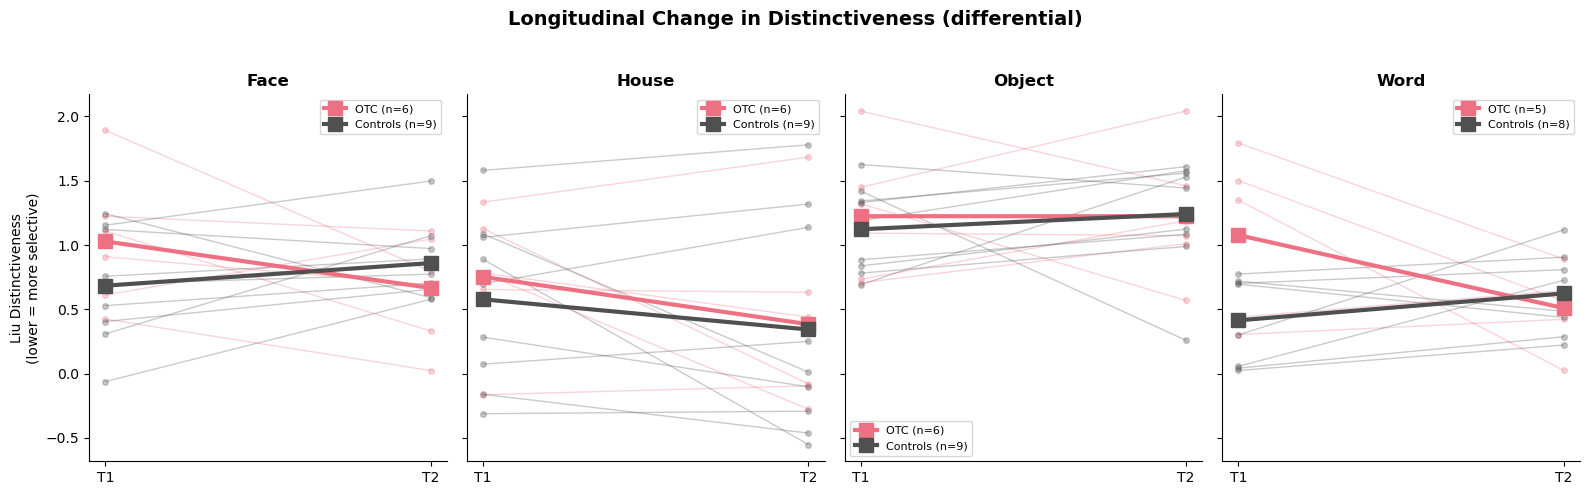

  Saved: fig_trajectories_differential.png
  MDS embedding plots for: ['OTC004', 'OTC008', 'OTC010', 'control018']
  NOTE: Requires recomputing from NIfTI data.
  For publication, run this in the geometry notebook where sphere/beta
  extraction functions are available, or save RDMs in script 09.
  Skipping automated plot — use individual notebook cells instead.


In [18]:
# %%
# FIGURE: Longitudinal Trajectories (T1 → T2 distinctiveness)

def fig_longitudinal_trajectories(cope_set='differential'):
    """Individual T1→T2 trajectories for OTC vs Controls, per category."""
    liu_file = LIU_DIR / f'liu_distinctiveness_{cope_set}.csv'
    if not liu_file.exists():
        print(f'  SKIP: {liu_file}')
        return

    df = pd.read_csv(liu_file)
    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]

        for grp, color, label in [('OTC', OTC_R, 'OTC'), ('control', CTRL_R, 'Controls')]:
            t1_vals, t2_vals = [], []

            for sid in df['subject_id'].unique():
                sd = df[(df['subject_id'] == sid) & (df['group'] == grp) &
                        (df['category'] == cat) & (df['hemi_label'].isin(['intact', 'left', 'right']))]
                sessions = sorted(sd['session'].unique())
                if len(sessions) < 2:
                    continue

                v1 = sd[sd['session'] == sessions[0]]['liu_distinctiveness']
                v2 = sd[sd['session'] == sessions[-1]]['liu_distinctiveness']
                if len(v1) > 0 and len(v2) > 0:
                    y1, y2 = v1.values[0], v2.values[0]
                    ax.plot([0, 1], [y1, y2], '-o', color=color,
                           alpha=0.3, markersize=4, linewidth=1)
                    t1_vals.append(y1)
                    t2_vals.append(y2)

            if t1_vals:
                ax.plot([0, 1], [np.mean(t1_vals), np.mean(t2_vals)], '-s',
                       color=color, linewidth=3, markersize=10,
                       label=f'{label} (n={len(t1_vals)})', zorder=10)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['T1', 'T2'])
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')
        ax.legend(fontsize=8)

    plt.suptitle(f'Longitudinal Change in Distinctiveness ({cope_set})',
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_trajectories_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_trajectories_{cope_set}.png')

fig_longitudinal_trajectories(COPE_SET)

# %%
# FIGURE: MDS Embeddings T1 vs T2 (example patients + control)

def fig_mds_embeddings(cope_set='differential'):
    """Actual 2D MDS plots for select patients showing T1 and T2 overlaid."""
    from scipy.linalg import orthogonal_procrustes

    geo_file = GEO_DIR / f'geometry_{cope_set}.csv'
    if not geo_file.exists():
        print(f'  SKIP: {geo_file}')
        return

    # We need to recompute MDS from raw data since CSVs don't store coordinates
    # Read the geometry CSV to identify which patients to plot
    gdf = pd.read_csv(geo_file)
    otc_subs = sorted(gdf[gdf['group'] == 'OTC']['subject'].unique())
    ctrl_subs = sorted(gdf[gdf['group'] == 'control']['subject'].unique())

    # Pick up to 3 OTC + 1 control
    plot_subs = otc_subs[:3] + ctrl_subs[:1]
    n = len(plot_subs)

    print(f"  MDS embedding plots for: {plot_subs}")
    print(f"  NOTE: Requires recomputing from NIfTI data.")
    print(f"  For publication, run this in the geometry notebook where sphere/beta")
    print(f"  extraction functions are available, or save RDMs in script 09.")
    print(f"  Skipping automated plot — use individual notebook cells instead.")

fig_mds_embeddings(COPE_SET)

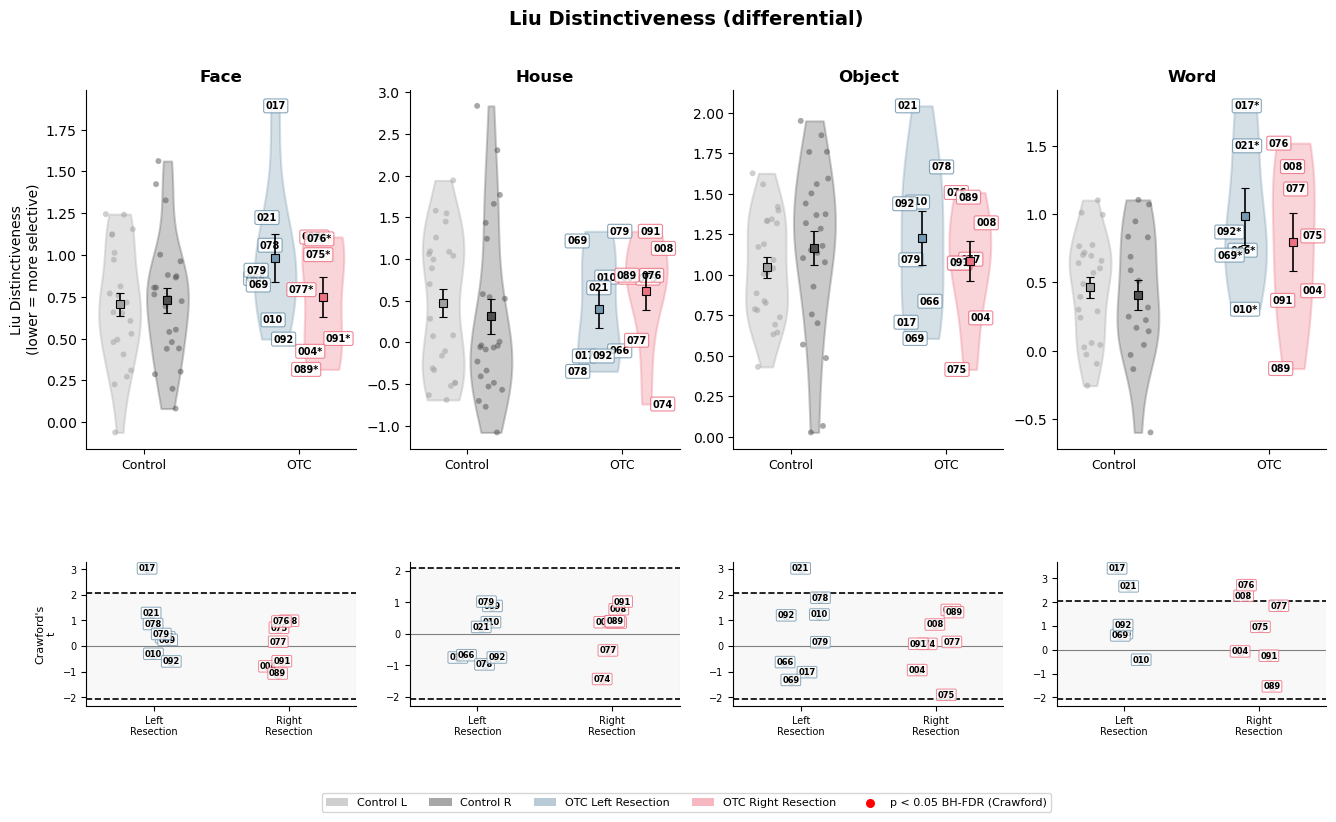

  Saved: fig_liu_differential.png


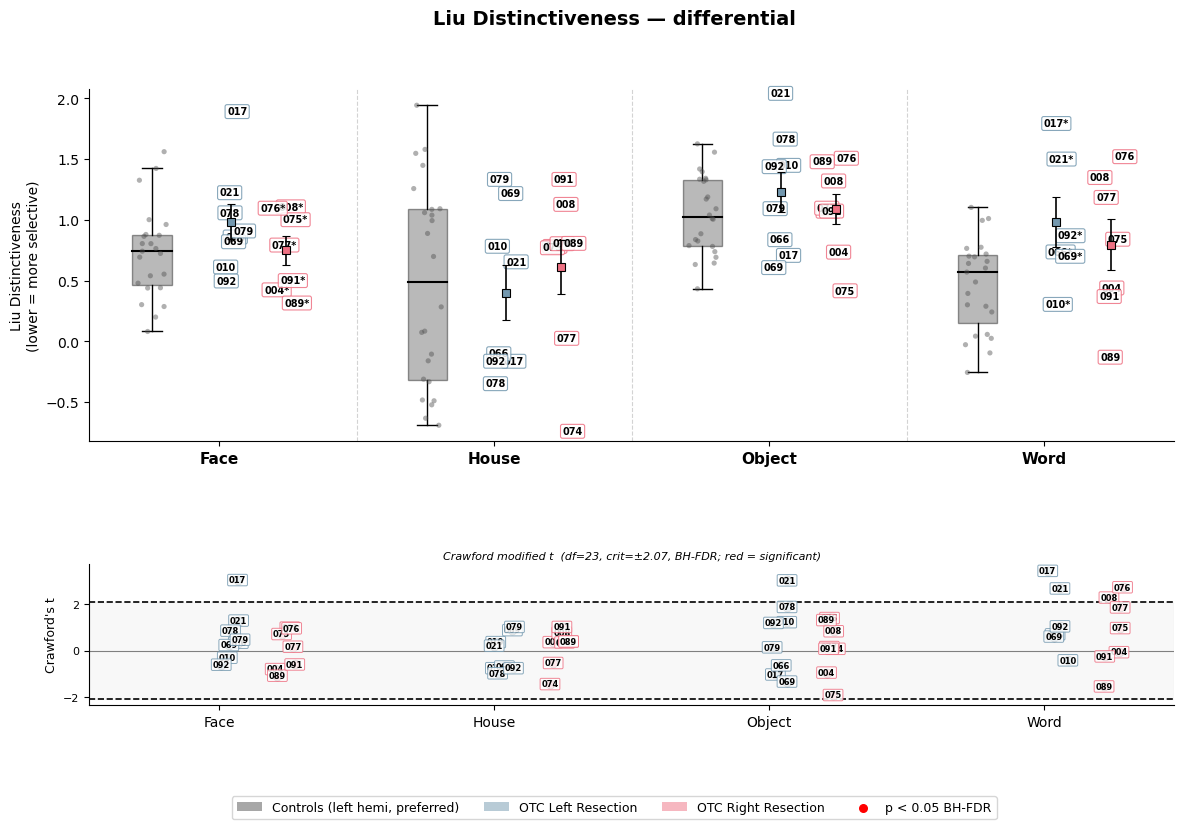

  Saved: fig_liu_differential_liu_style.png


In [20]:
# ── Crawford helper ───────────────────────────────────────────────────────────

# Preferred hemisphere for Crawford comparison per category
# (controls' hemi_label to use as the reference distribution)
PREFERRED_CTRL_HEMI = {'face': 'right', 'word': 'left', 'house': 'left', 'object': 'left'}

def crawford_t(patient_val, ctrl_vals):
    """Crawford & Howell (1998) modified t-test: single case vs controls.
    Returns (t_stat, p_val, n_controls)."""
    ctrl_vals = np.asarray(ctrl_vals)
    ctrl_vals = ctrl_vals[np.isfinite(ctrl_vals)]
    n = len(ctrl_vals)
    if n < 3:
        return np.nan, np.nan, n
    m, s = ctrl_vals.mean(), ctrl_vals.std(ddof=1)
    if s == 0:
        return np.nan, np.nan, n
    t = (patient_val - m) / (s * np.sqrt((n + 1) / n))
    from scipy import stats
    p = 2 * stats.t.sf(abs(t), df=n - 1)   # two-tailed
    return t, p, n


def _bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR. Returns boolean rejected array (same order as input)."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    if n == 0:
        return np.array([], dtype=bool)
    order = np.argsort(pvals)
    ranked = np.empty(n)
    ranked[order] = np.arange(1, n + 1)
    threshold = (ranked / n) * alpha
    below = pvals <= threshold
    if not below.any():
        return np.zeros(n, dtype=bool)
    cutoff = pvals[order[np.where(below)[0].max()]]
    return pvals <= cutoff


def _load_liu_first_session(cope_set):
    """Load liu_distinctiveness CSV, return (ctrl, otc) first-session DataFrames."""
    liu_file = LIU_DIR / f'liu_distinctiveness_{cope_set}.csv'
    if not liu_file.exists():
        print(f'  SKIP: {liu_file} not found')
        return None, None
    df = pd.read_csv(liu_file)
    first = df.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    df = df.merge(first, on='subject_id')
    df = df[df['session'] == df['fs']]
    ctrl = df[df['status'] == 'control'].copy()
    otc  = df[(df['group'] == 'OTC') & (df['hemi_label'] == 'intact')].copy()
    return ctrl, otc


def _compute_crawford_rows(ctrl, otc):
    """Compute Crawford t/p for every patient × category.
    Returns DataFrame with columns: subject, surgery_side, category, t, p, sig (after BH-FDR)."""
    rows = []
    for cat in CATEGORIES:
        ref_hemi = PREFERRED_CTRL_HEMI[cat]
        ctrl_vals = ctrl[(ctrl['category'] == cat) &
                         (ctrl['hemi_label'] == ref_hemi)]['liu_distinctiveness'].values
        for _, row in otc[otc['category'] == cat].iterrows():
            t, p, _ = crawford_t(row['liu_distinctiveness'], ctrl_vals)
            rows.append({'subject': row['subject'],
                         'surgery_side': row['surgery_side'],
                         'category': cat, 't': t, 'p': p})
    cdf = pd.DataFrame(rows)
    # BH-FDR across all patient × category comparisons
    valid = cdf['p'].notna()
    cdf.loc[:, 'sig'] = False
    if valid.sum() > 0:
        cdf.loc[valid, 'sig'] = _bh_fdr(cdf.loc[valid, 'p'].values)
    return cdf


# ── FIGURE 2a: 4-panel layout + Crawford strip ───────────────────────────────

def fig_liu_distinctiveness(cope_set='differential'):
    """4-panel violin+jitter (Controls L/R vs OTC-left/right) with Crawford
    t-score strip below each panel."""
    ctrl, otc = _load_liu_first_session(cope_set)
    if ctrl is None:
        return
    cdf = _compute_crawford_rows(ctrl, otc)

    # Critical value for two-tailed α=0.05, df = n_ctrl-1
    from scipy import stats
    n_ctrl = ctrl['subject_id'].nunique()
    t_crit = stats.t.ppf(0.975, df=n_ctrl - 1)

    fig = plt.figure(figsize=(16, 8))
    gs  = fig.add_gridspec(2, 4, height_ratios=[3, 1.2], hspace=0.45)

    for col_idx, cat in enumerate(CATEGORIES):
        ax  = fig.add_subplot(gs[0, col_idx])
        axc = fig.add_subplot(gs[1, col_idx])

        # ── Top: violin + jitter ─────────────────────────────────────────────
        vd, vp, vc = [], [], []
        ref_hemi   = PREFERRED_CTRL_HEMI[cat]
        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'left')]['liu_distinctiveness'].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'right')]['liu_distinctiveness'].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd   = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd['liu_distinctiveness'].values
            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)
            for _, row in sd.iterrows():
                jit  = RNG.uniform(-0.18, 0.18)
                lbl  = short_name(row['subject'])
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f'{lbl}{star}', (pos + jit, row['liu_distinctiveness']),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=color, alpha=0.85, linewidth=0.8),
                            zorder=4)
            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                            color='black', marker='s', markersize=6,
                            markerfacecolor=color, markeredgecolor='black',
                            markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i]); body.set_alpha(0.3)
                body.set_edgecolor(vc[i]); body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')

        # ── Bottom: Crawford t-scores ────────────────────────────────────────
        cat_cdf = cdf[cdf['category'] == cat]
        axc.axhline(0,       color='gray',  linewidth=0.8, linestyle='-')
        axc.axhline( t_crit, color='black', linewidth=1.2, linestyle='--')
        axc.axhline(-t_crit, color='black', linewidth=1.2, linestyle='--')

        x_pos = {'left': 0.0, 'right': 1.0}
        for _, r in cat_cdf.iterrows():
            if np.isnan(r['t']):
                continue
            x   = x_pos[r['surgery_side']] + RNG.uniform(-0.15, 0.15)
            col = OTC_L if r['surgery_side'] == 'left' else OTC_R
            dot_color = 'red' if r['sig'] else col
            axc.scatter(x, r['t'], color=dot_color, s=40, zorder=4,
                        edgecolors='black', linewidth=0.5)
            lbl = short_name(r['subject'])
            axc.annotate(lbl, (x, r['t']), fontsize=6, fontweight='bold',
                         ha='center', va='center',
                         bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                                   edgecolor=dot_color, alpha=0.85, linewidth=0.7),
                         zorder=5)

        axc.set_xlim(-0.5, 1.5)
        axc.set_xticks([0.0, 1.0])
        axc.set_xticklabels(['Left\nResection', 'Right\nResection'], fontsize=7)
        axc.set_ylabel("Crawford's\nt" if col_idx == 0 else '', fontsize=8)
        axc.axhspan(-t_crit, t_crit, alpha=0.05, color='gray')  # normal range shading
        axc.tick_params(axis='y', labelsize=7)

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection'),
        plt.scatter([], [], color='red', s=30, label=f'p < 0.05 BH-FDR (Crawford)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=5, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.03))

    plt.suptitle(f'Liu Distinctiveness ({cope_set})', fontsize=14, fontweight='bold')
    plt.savefig(str(FIG_DIR / f'fig_liu_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_liu_{cope_set}.png')


# ── FIGURE 2b: Liu-style single-axis boxplot + Crawford strip ─────────────────

def fig_liu_distinctiveness_liu_style(cope_set='differential'):
    """Liu Fig.3D-style: single plot, boxplots for controls, badges for patients,
    with Crawford t-score companion panel below."""
    ctrl, otc = _load_liu_first_session(cope_set)
    if ctrl is None:
        return
    cdf = _compute_crawford_rows(ctrl, otc)

    from scipy import stats
    n_ctrl = ctrl['subject_id'].nunique()
    t_crit = stats.t.ppf(0.975, df=n_ctrl - 1)

    # X positions: for each category, controls boxplot + OTC-left + OTC-right
    # spacing: categories spaced 3 units apart, within-category: ctrl=0, otc-l=1, otc-r=1.6
    cat_centers = {cat: i * 3.5 for i, cat in enumerate(CATEGORIES)}
    offsets = {'control': 0.0, 'left': 1.0, 'right': 1.7}

    fig = plt.figure(figsize=(14, 8))
    gs  = fig.add_gridspec(2, 1, height_ratios=[3, 1.2], hspace=0.5)
    ax  = fig.add_subplot(gs[0])
    axc = fig.add_subplot(gs[1])

    # ── Top panel ────────────────────────────────────────────────────────────
    xtick_positions, xtick_labels = [], []

    for cat in CATEGORIES:
        cx = cat_centers[cat]
        ref_hemi = PREFERRED_CTRL_HEMI[cat]

        # Controls: single boxplot using preferred hemi
        ctrl_vals = ctrl[(ctrl['category'] == cat) &
                         (ctrl['hemi_label'] == ref_hemi)]['liu_distinctiveness'].values
        bx = cx + offsets['control']
        if len(ctrl_vals) >= 2:
            bp = ax.boxplot(ctrl_vals, positions=[bx], widths=0.5,
                            patch_artist=True, showfliers=False,
                            medianprops=dict(color='black', linewidth=1.5),
                            boxprops=dict(facecolor=CTRL_R, alpha=0.4),
                            whiskerprops=dict(linewidth=1),
                            capprops=dict(linewidth=1))
            # Individual control dots
            jit = RNG.uniform(-0.18, 0.18, len(ctrl_vals))
            ax.scatter(np.full(len(ctrl_vals), bx) + jit, ctrl_vals,
                       color=CTRL_R, alpha=0.45, s=14, zorder=3, edgecolors='none')

        # OTC patients
        for side, color in [('left', OTC_L), ('right', OTC_R)]:
            px = cx + offsets[side]
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            for _, row in sd.iterrows():
                jit  = RNG.uniform(-0.18, 0.18)
                lbl  = short_name(row['subject'])
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f'{lbl}{star}', (px + jit, row['liu_distinctiveness']),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=color, alpha=0.85, linewidth=0.8),
                            zorder=4)
            vals = sd['liu_distinctiveness'].values
            if len(vals) > 0:
                ax.errorbar(px, np.mean(vals), yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                            color='black', marker='s', markersize=6,
                            markerfacecolor=color, markeredgecolor='black',
                            markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # Category label at group midpoint
        mid = cx + (offsets['control'] + offsets['right']) / 2
        xtick_positions.append(mid)
        xtick_labels.append(cat.title())

        # Divider between categories
        if cat != CATEGORIES[-1]:
            ax.axvline(cx + 2.6, color='lightgray', linewidth=0.8, linestyle='--', zorder=0)

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=11, fontweight='bold')
    ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')
    ax.set_xlim(-0.8, max(cat_centers.values()) + 2.5)

    # ── Bottom: Crawford t-scores (one dot per patient per category) ─────────
    # X positions matching top panel OTC positions
    axc.axhline(0,       color='gray',  linewidth=0.8)
    axc.axhline( t_crit, color='black', linewidth=1.2, linestyle='--')
    axc.axhline(-t_crit, color='black', linewidth=1.2, linestyle='--')
    axc.axhspan(-t_crit, t_crit, alpha=0.05, color='gray')

    for cat in CATEGORIES:
        cx = cat_centers[cat]
        cat_cdf = cdf[cdf['category'] == cat]
        for _, r in cat_cdf.iterrows():
            if np.isnan(r['t']):
                continue
            px  = cx + offsets[r['surgery_side']]
            col = OTC_L if r['surgery_side'] == 'left' else OTC_R
            dot_color = 'red' if r['sig'] else col
            x   = px + RNG.uniform(-0.15, 0.15)
            axc.scatter(x, r['t'], color=dot_color, s=40, zorder=4,
                        edgecolors='black', linewidth=0.5)
            axc.annotate(short_name(r['subject']), (x, r['t']),
                         fontsize=6, fontweight='bold', ha='center', va='center',
                         bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                                   edgecolor=dot_color, alpha=0.85, linewidth=0.7),
                         zorder=5)

    axc.set_xlim(-0.8, max(cat_centers.values()) + 2.5)
    axc.set_xticks(xtick_positions)
    axc.set_xticklabels(xtick_labels, fontsize=10)
    axc.set_ylabel("Crawford's t", fontsize=9)
    axc.tick_params(axis='y', labelsize=8)
    axc.set_title(f'Crawford modified t  (df={n_ctrl-1}, crit=±{t_crit:.2f}, BH-FDR; '
                  f'red = significant)', fontsize=8, style='italic', pad=4)

    legend_elements = [
        Patch(facecolor=CTRL_R, alpha=0.5, label=f'Controls ({ref_hemi} hemi, preferred)'),
        Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection'),
        plt.scatter([], [], color='red', s=30, label='p < 0.05 BH-FDR'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))

    plt.suptitle(f'Liu Distinctiveness — {cope_set}', fontsize=14, fontweight='bold')
    plt.savefig(str(FIG_DIR / f'fig_liu_{cope_set}_liu_style.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_liu_{cope_set}_liu_style.png')


# ── Run ───────────────────────────────────────────────────────────────────────

fig_liu_distinctiveness(COPE_SET)
fig_liu_distinctiveness_liu_style(COPE_SET)

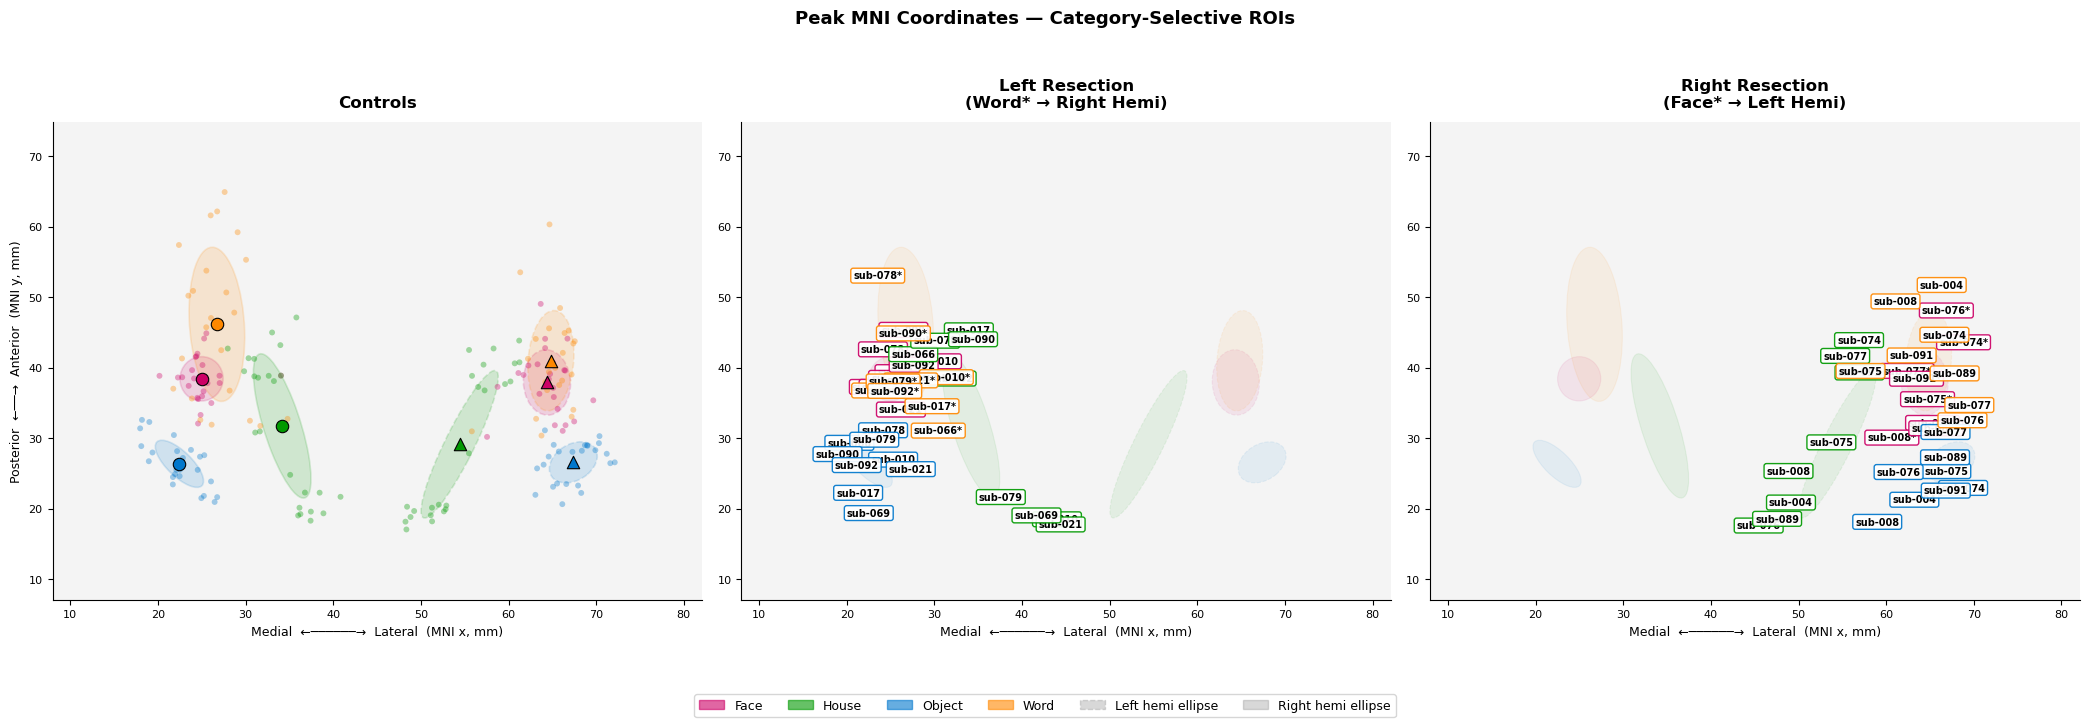

  Saved: fig_peak_coords.png


In [25]:
CAT_COLORS = {
    'face':   '#cc0066',
    'word':   '#ff8800',
    'house':  '#009900',
    'object': '#0077cc',
}

def _confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    """Draw a covariance ellipse for x,y. n_std = radius in SDs."""
    from matplotlib.patches import Ellipse
    import matplotlib.transforms as transforms
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx, ry = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2, **kwargs)
    sx = np.sqrt(cov[0, 0]) * n_std
    sy = np.sqrt(cov[1, 1]) * n_std
    t = (transforms.Affine2D()
         .rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)


def fig_peak_coordinates(suffix=''):
    """Liu Fig.2-style 2D MNI scatter, split by hemisphere within each panel.
    Controls: 1-SD ellipse + dots per hemi. OTC: labeled badges."""

    pk_file = Path(f'{processed_dir}/group_results/peak_coords/peak_coords{suffix}.csv')
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)
    first = df.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'fs'})
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')
    # OTC: intact hemisphere only
    otc = otc[((otc['intact_hemi'] == 'left')  & (otc['hemi'] == 'left')) |
              ((otc['intact_hemi'] == 'right') & (otc['hemi'] == 'right'))]

    panels = [
        (ctrl,                               None,    'Controls'),
        (otc[otc['surgery_side'] == 'left'],  'left',  'Left Resection\n(Word* → Right Hemi)'),
        (otc[otc['surgery_side'] == 'right'], 'right', 'Right Resection\n(Face* → Left Hemi)'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.patch.set_facecolor('white')

    # Shared axis limits from all control data
    pad = 10
    xlim = (ctrl['peak_x_mni'].min() - pad, ctrl['peak_x_mni'].max() + pad)
    ylim = (ctrl['peak_y_mni'].min() - pad, ctrl['peak_y_mni'].max() + pad)

    for ax_idx, (pdata, side, title) in enumerate(panels):
        ax = axes[ax_idx]
        ax.set_facecolor('#f4f4f4')
        is_ctrl = (side is None)

        for cat in CATEGORIES:
            color = CAT_COLORS[cat]

            if is_ctrl:
                # ── Draw separately for each hemisphere ──────────────────────
                for hemi, linestyle in [('left', '--'), ('right', '-')]:
                    hdat = pdata[(pdata['category'] == cat) &
                                 (pdata['hemi'] == hemi)].dropna(
                                     subset=['peak_x_mni', 'peak_y_mni'])
                    x, y = hdat['peak_x_mni'].values, hdat['peak_y_mni'].values
                    if len(x) < 2:
                        continue
                    # Ellipse
                    if len(x) >= 3:
                        _confidence_ellipse(x, y, ax, n_std=1.0,
                                            facecolor=color, alpha=0.15,
                                            edgecolor=color, linewidth=1.2,
                                            linestyle=linestyle, zorder=2)
                    # Individual dots
                    ax.scatter(x, y, color=color, alpha=0.35, s=18,
                               edgecolors='none', zorder=3)
                    # Centroid
                    ax.scatter(np.mean(x), np.mean(y), color=color, s=80,
                               edgecolors='black', linewidth=0.8,
                               marker='o' if hemi == 'right' else '^',
                               zorder=5)

            else:
                # ── Faint control ellipses as reference (split by hemi) ───────
                for hemi, linestyle in [('left', '--'), ('right', '-')]:
                    ctrl_hdat = ctrl[(ctrl['category'] == cat) &
                                     (ctrl['hemi'] == hemi)].dropna(
                                         subset=['peak_x_mni', 'peak_y_mni'])
                    cx, cy = ctrl_hdat['peak_x_mni'].values, ctrl_hdat['peak_y_mni'].values
                    if len(cx) >= 3:
                        _confidence_ellipse(cx, cy, ax, n_std=1.0,
                                            facecolor=color, alpha=0.07,
                                            edgecolor=color, linewidth=0.8,
                                            linestyle=linestyle, zorder=1)

                # ── Patient badges ────────────────────────────────────────────
                pcat = pdata[pdata['category'] == cat].dropna(
                    subset=['peak_x_mni', 'peak_y_mni'])
                for _, row in pcat.iterrows():
                    lbl  = short_name(row['sub'])
                    star = '*' if REORG.get(side) == cat else ''
                    ax.annotate(
                        f'{lbl}{star}',
                        (row['peak_x_mni'], row['peak_y_mni']),
                        fontsize=7, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                                  edgecolor=color, alpha=0.92, linewidth=1.0),
                        zorder=6)

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.axvline(0, color='gray', linewidth=0.7, linestyle='--', alpha=0.4, zorder=1)
        ax.set_xlabel('Medial  ←──────→  Lateral  (MNI x, mm)', fontsize=9)
        if ax_idx == 0:
            ax.set_ylabel('Posterior  ←──→  Anterior  (MNI y, mm)', fontsize=9)
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        ax.tick_params(labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_cats = [Patch(facecolor=CAT_COLORS[cat], alpha=0.6,
                         edgecolor=CAT_COLORS[cat], label=cat.title())
                   for cat in CATEGORIES]
    legend_hemi = [
        Patch(facecolor='gray', alpha=0.3, edgecolor='gray',
              linestyle='--', label='Left hemi ellipse'),
        Patch(facecolor='gray', alpha=0.3, edgecolor='gray',
              linestyle='-',  label='Right hemi ellipse'),
    ]
    fig.legend(handles=legend_cats + legend_hemi,
               loc='lower center', ncol=6, fontsize=9,
               frameon=True, bbox_to_anchor=(0.5, -0.04))

    suf_label = f' [{suffix[1:]}]' if suffix else ''
    plt.suptitle(f'Peak MNI Coordinates — Category-Selective ROIs{suf_label}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.06, 1, 0.95])

    out = FIG_DIR / f'fig_peak_coords{suffix}.png'
    plt.savefig(str(out), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out.name}')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_peak_coordinates()

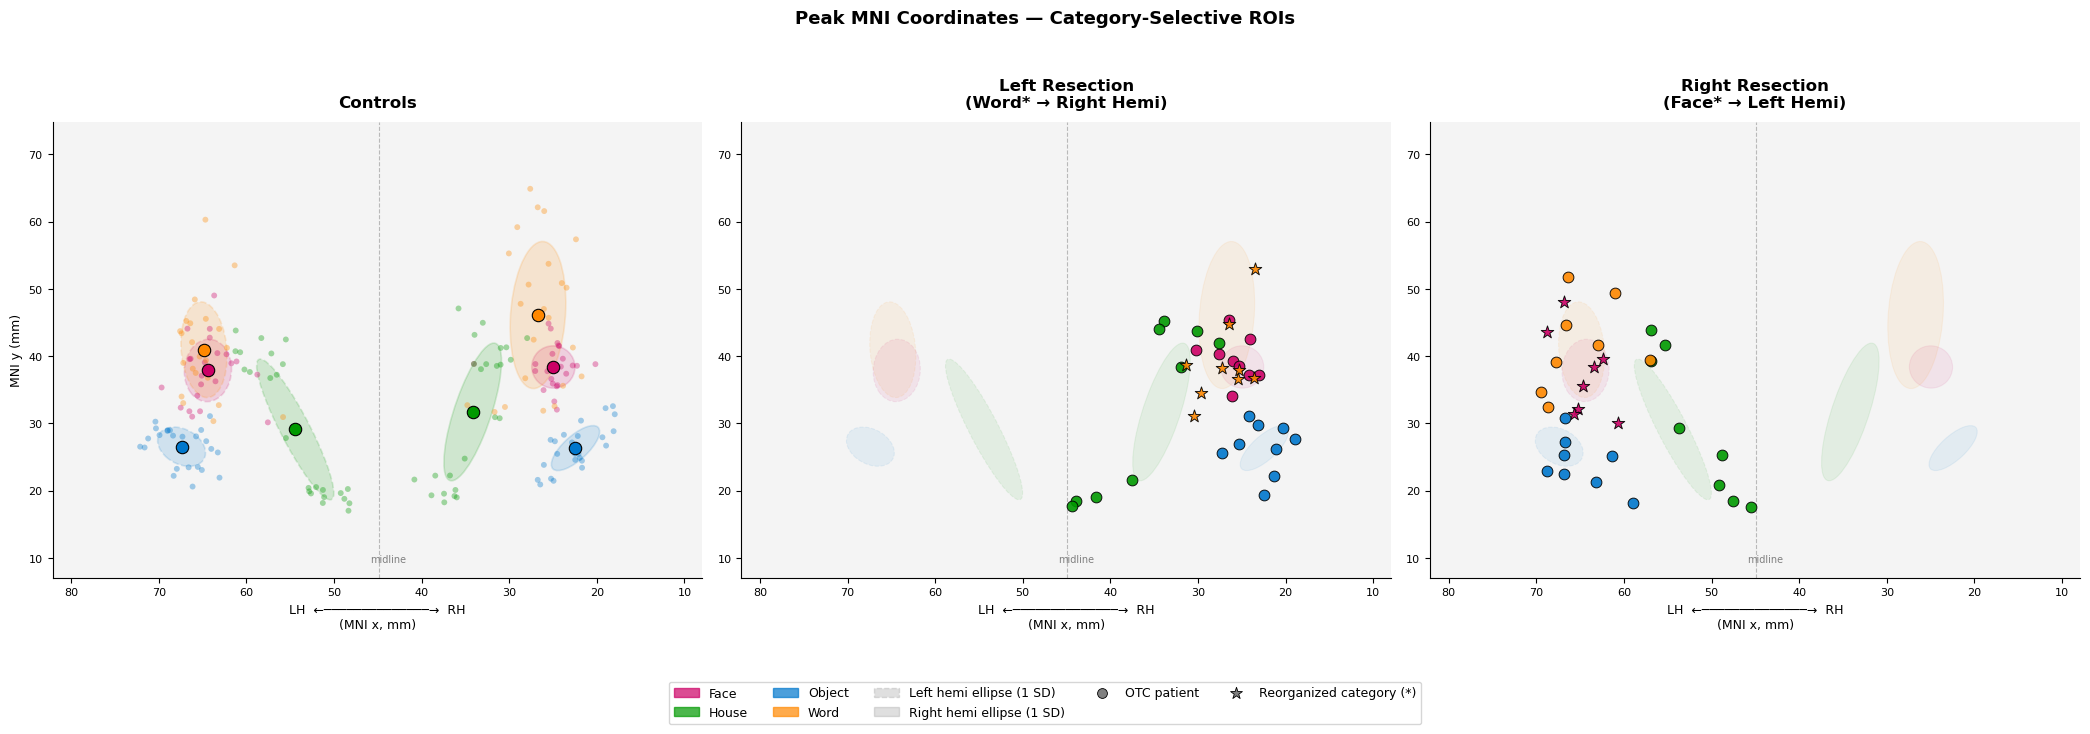

  Saved: fig_peak_coords.png


In [31]:
CAT_COLORS = {
    'face':   '#cc0066',
    'word':   '#ff8800',
    'house':  '#009900',
    'object': '#0077cc',
}

def _confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    from matplotlib.patches import Ellipse
    import matplotlib.transforms as transforms
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx, ry = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2, **kwargs)
    sx = np.sqrt(cov[0, 0]) * n_std
    sy = np.sqrt(cov[1, 1]) * n_std
    t = (transforms.Affine2D()
         .rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)


def fig_peak_coordinates(suffix=''):
    """Liu Fig.2-style 2D MNI scatter, hemisphere-split ellipses.
    Controls: ellipse + small dots. Patients: larger dots, shape = surgery side."""

    pk_file = Path(f'{processed_dir}/group_results/peak_coords/peak_coords{suffix}.csv')
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)
    first = df.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'fs'})
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')
    otc = otc[((otc['intact_hemi'] == 'left')  & (otc['hemi'] == 'left')) |
              ((otc['intact_hemi'] == 'right') & (otc['hemi'] == 'right'))]

    # Empirical midline: midpoint between mean left and right hemi x
    lx = ctrl[ctrl['hemi'] == 'left']['peak_x_mni'].mean()
    rx = ctrl[ctrl['hemi'] == 'right']['peak_x_mni'].mean()
    midline_x = (lx + rx) / 2

    panels = [
        (ctrl,                               None,    'Controls'),
        (otc[otc['surgery_side'] == 'left'],  'left',  'Left Resection\n(Word* → Right Hemi)'),
        (otc[otc['surgery_side'] == 'right'], 'right', 'Right Resection\n(Face* → Left Hemi)'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.patch.set_facecolor('white')

    pad = 10
    xlim = (ctrl['peak_x_mni'].min() - pad, ctrl['peak_x_mni'].max() + pad)
    ylim = (ctrl['peak_y_mni'].min() - pad, ctrl['peak_y_mni'].max() + pad)

    for ax_idx, (pdata, side, title) in enumerate(panels):
        ax = axes[ax_idx]
        ax.set_facecolor('#f4f4f4')
        is_ctrl = (side is None)

        for cat in CATEGORIES:
            color = CAT_COLORS[cat]

            # ── Control ellipses (both panels) ────────────────────────────────
            for hemi, ls in [('left', '--'), ('right', '-')]:
                hdat = ctrl[(ctrl['category'] == cat) &
                            (ctrl['hemi'] == hemi)].dropna(
                                subset=['peak_x_mni', 'peak_y_mni'])
                x, y = hdat['peak_x_mni'].values, hdat['peak_y_mni'].values
                alpha = 0.15 if is_ctrl else 0.07
                lw    = 1.2  if is_ctrl else 0.8
                if len(x) >= 3:
                    _confidence_ellipse(x, y, ax, n_std=1.0,
                                        facecolor=color, alpha=alpha,
                                        edgecolor=color, linewidth=lw,
                                        linestyle=ls, zorder=2)
                if is_ctrl:
                    ax.scatter(x, y, color=color, alpha=0.35, s=18,
                               edgecolors='none', zorder=3)
                    if len(x) >= 2:
                        ax.scatter(np.mean(x), np.mean(y), color=color, s=80,
                                   edgecolors='black', linewidth=0.8, zorder=5,
                                   marker='o')

            # ── Patient dots ──────────────────────────────────────────────────
            if not is_ctrl:
                pcat = pdata[pdata['category'] == cat].dropna(
                    subset=['peak_x_mni', 'peak_y_mni'])
                # marker encodes surgery side: circle = right resection, triangle = left
                marker = '^' if side == 'left' else 'o'
                # star marker for reorganized category
                for _, row in pcat.iterrows():
                    is_reorg = (REORG.get(side) == cat)
                    ax.scatter(row['peak_x_mni'], row['peak_y_mni'],
                               color=color, s=90 if is_reorg else 60,
                               marker='*' if is_reorg else 'o',
                               edgecolors='black', linewidth=0.7,
                               alpha=0.9, zorder=6)

        # Empirical midline
        ax.axvline(midline_x, color='gray', linewidth=0.8,
                   linestyle='--', alpha=0.5, zorder=1)
        ax.text(midline_x + 1, ylim[0] + 2, 'midline',
                fontsize=7, color='gray', va='bottom')

        ax.set_xlim(xlim)
        ax.invert_xaxis()  # left hemi (high x) on left, right hemi (low x) on right
        ax.set_ylim(ylim)
        ax.set_xlabel('LH  ←──────────────→  RH\n(MNI x, mm)', fontsize=9)
        if ax_idx == 0:
            ax.set_ylabel('MNI y (mm)', fontsize=9)
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        ax.tick_params(labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)

    # ── Legend ────────────────────────────────────────────────────────────────
    leg_cats = [Patch(facecolor=CAT_COLORS[c], alpha=0.7,
                      edgecolor=CAT_COLORS[c], label=c.title())
                for c in CATEGORIES]
    leg_style = [
        Patch(facecolor='gray', alpha=0.25, edgecolor='gray',
              linestyle='--', label='Left hemi ellipse (1 SD)'),
        Patch(facecolor='gray', alpha=0.25, edgecolor='gray',
              linestyle='-',  label='Right hemi ellipse (1 SD)'),
        plt.scatter([], [], color='gray', marker='o', s=50,
                    edgecolors='black', linewidth=0.6, label='OTC patient'),
        plt.scatter([], [], color='gray', marker='*', s=80,
                    edgecolors='black', linewidth=0.6, label='Reorganized category (*)'),
    ]
    fig.legend(handles=leg_cats + leg_style,
               loc='lower center', ncol=5, fontsize=9,
               frameon=True, bbox_to_anchor=(0.5, -0.05))

    suf_label = f' [{suffix[1:]}]' if suffix else ''
    plt.suptitle(f'Peak MNI Coordinates — Category-Selective ROIs{suf_label}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])

    out = FIG_DIR / f'fig_peak_coords{suffix}.png'
    plt.savefig(str(out), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out.name}')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_peak_coordinates()

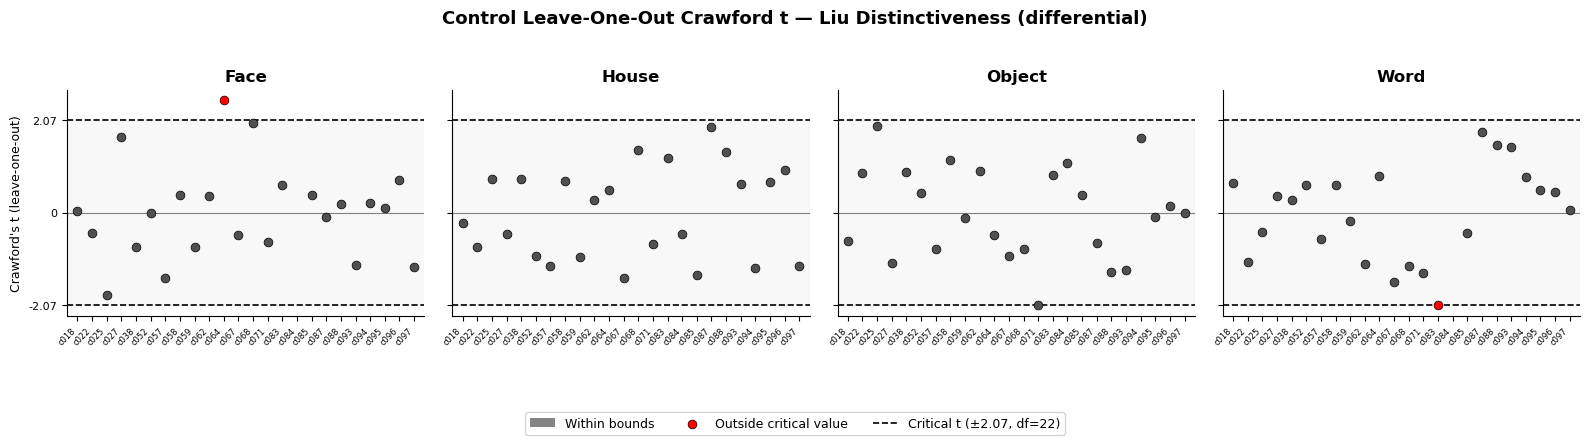

  Saved: fig_crawford_controls_differential.png


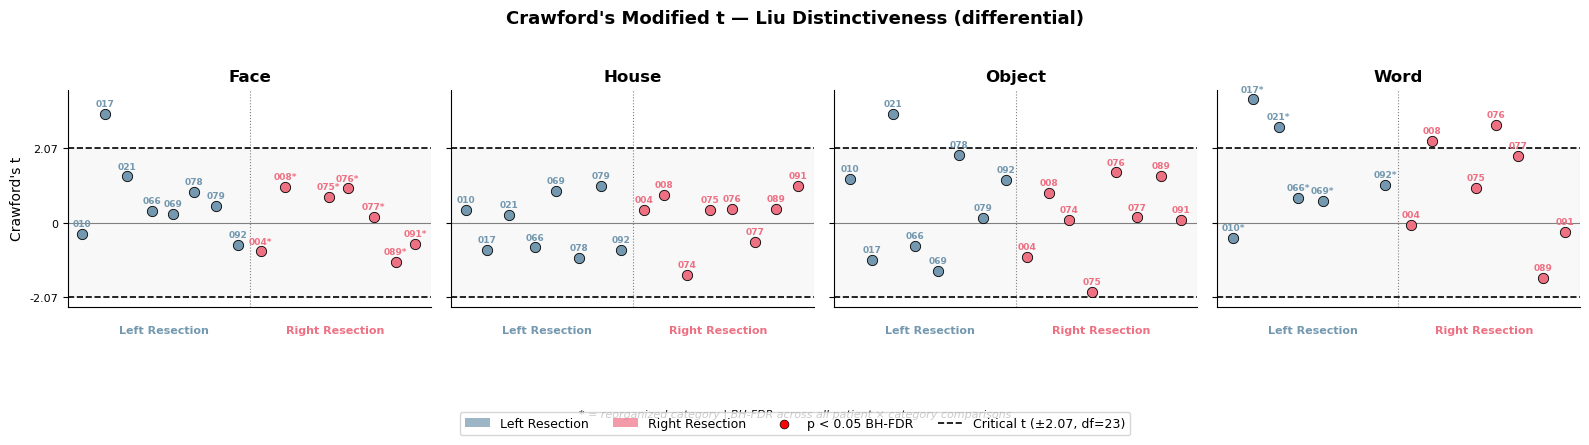

  Saved: fig_crawford_differential.png


In [36]:
from scipy import stats as sp_stats

# ── Shared: compute leave-one-out Crawford t for controls ─────────────────────

def _compute_crawford_controls(ctrl):
    """Leave-one-out Crawford t for each control × category.
    Each control is tested against the remaining n-1 controls."""
    rows = []
    for cat in CATEGORIES:
        ref_hemi = PREFERRED_CTRL_HEMI[cat]
        cat_ctrl = ctrl[(ctrl['category'] == cat) &
                        (ctrl['hemi_label'] == ref_hemi)]
        all_vals = cat_ctrl['liu_distinctiveness'].values
        for _, row in cat_ctrl.iterrows():
            loo_vals = all_vals[all_vals != row['liu_distinctiveness']]
            t, p, _  = crawford_t(row['liu_distinctiveness'], loo_vals)
            rows.append({'subject': row['subject'],
                         'category': cat, 't': t, 'p': p})
    return pd.DataFrame(rows)


# ── FIGURE: Individual control Crawford t-scores (Liu Fig 2J equivalent) ──────

def fig_crawford_controls(cope_set='differential'):
    """Leave-one-out Crawford t for each control, 4 panels (one per category).
    Validates that controls fall within critical bounds."""
    ctrl, _ = _load_liu_first_session(cope_set)
    if ctrl is None:
        return

    cdf     = _compute_crawford_controls(ctrl)
    n_ctrl  = ctrl['subject_id'].nunique()
    t_crit  = sp_stats.t.ppf(0.975, df=n_ctrl - 2)  # df = n-2 for LOO

    ctrl_subs = sorted(cdf['subject'].unique(), key=lambda s: short_name(s))
    sub_x     = {s: i + 1 for i, s in enumerate(ctrl_subs)}

    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

    for col_idx, cat in enumerate(CATEGORIES):
        ax      = axes[col_idx]
        cat_cdf = cdf[cdf['category'] == cat]

        ax.axhline(0,       color='gray',  linewidth=0.8, zorder=1)
        ax.axhline( t_crit, color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhline(-t_crit, color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhspan(-t_crit, t_crit, alpha=0.05, color='gray', zorder=0)

        for _, row in cat_cdf.iterrows():
            if np.isnan(row['t']):
                continue
            x         = sub_x[row['subject']]
            is_out    = abs(row['t']) > t_crit
            dot_color = 'red' if is_out else CTRL_R
            ax.scatter(x, row['t'], color=dot_color, s=40, zorder=4,
                       edgecolors='black', linewidth=0.5)

        ax.set_xlim(0.3, len(ctrl_subs) + 0.7)
        ax.set_xticks(list(sub_x.values()))
        ax.set_xticklabels([short_name(s) for s in ctrl_subs],
                           fontsize=6, rotation=45, ha='right')
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel("Crawford's t (leave-one-out)", fontsize=9)
            ax.set_yticks([-t_crit, 0, t_crit])
            ax.set_yticklabels([f'{-t_crit:.2f}', '0', f'{t_crit:.2f}'], fontsize=8)

    legend_elements = [
        Patch(facecolor=CTRL_R, alpha=0.7, label='Within bounds'),
        plt.scatter([], [], color='red', s=40, edgecolors='black',
                    linewidth=0.5, label='Outside critical value'),
        plt.Line2D([0], [0], color='black', linewidth=1.2, linestyle='--',
                   label=f'Critical t (±{t_crit:.2f}, df={n_ctrl-2})'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.1))

    plt.suptitle(f"Control Leave-One-Out Crawford t — Liu Distinctiveness ({cope_set})",
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_crawford_controls_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_crawford_controls_{cope_set}.png')


# ── FIGURE: Patient Crawford t-scores (Liu Fig 3E equivalent) ─────────────────

def fig_crawford_distinctiveness(cope_set='differential'):
    """Crawford t-scores for OTC patients, 4 panels (one per category),
    patients on x-axis, colored by surgery side, red = BH-FDR significant."""
    ctrl, otc = _load_liu_first_session(cope_set)
    if ctrl is None:
        return
    cdf = _compute_crawford_rows(ctrl, otc)

    n_ctrl  = ctrl['subject_id'].nunique()
    t_crit  = sp_stats.t.ppf(0.975, df=n_ctrl - 1)

    left_pts  = sorted(cdf[cdf['surgery_side'] == 'left']['subject'].unique(),
                       key=lambda s: short_name(s))
    right_pts = sorted(cdf[cdf['surgery_side'] == 'right']['subject'].unique(),
                       key=lambda s: short_name(s))
    all_pts   = left_pts + right_pts
    pt_x      = {sub: i + 1 for i, sub in enumerate(all_pts)}
    divider_x = len(left_pts) + 0.5

    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

    for col_idx, cat in enumerate(CATEGORIES):
        ax      = axes[col_idx]
        cat_cdf = cdf[cdf['category'] == cat]

        ax.axhline(0,       color='gray',  linewidth=0.8, zorder=1)
        ax.axhline( t_crit, color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhline(-t_crit, color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhspan(-t_crit, t_crit, alpha=0.05, color='gray', zorder=0)
        ax.axvline(divider_x, color='gray', linewidth=0.8, linestyle=':', zorder=1)

        for _, row in cat_cdf.iterrows():
            if np.isnan(row['t']):
                continue
            x         = pt_x[row['subject']] + RNG.uniform(-0.1, 0.1)
            base_col  = OTC_L if row['surgery_side'] == 'left' else OTC_R
            dot_color = 'red' if row['sig'] else base_col
            star      = '*' if REORG.get(row['surgery_side']) == cat else ''
            ax.scatter(x, row['t'], color=dot_color, s=55, zorder=4,
                       edgecolors='black', linewidth=0.6)
            ax.annotate(f"{short_name(row['subject'])}{star}",
                        (x, row['t']), fontsize=6.5, fontweight='bold',
                        ha='center', va='bottom', xytext=(0, 4),
                        textcoords='offset points', color=dot_color)

        ax.set_xticks([])
        ax.set_xlim(0.3, len(all_pts) + 0.7)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel("Crawford's t", fontsize=10)
            ax.set_yticks([-t_crit, 0, t_crit])
            ax.set_yticklabels([f'{-t_crit:.2f}', '0', f'{t_crit:.2f}'], fontsize=8)

        # Group labels
        ax.text((len(left_pts) / 2 + 0.5) / (len(all_pts) + 1),
                -0.12, 'Left Resection', ha='center', fontsize=8,
                color=OTC_L, fontweight='bold',
                transform=ax.transAxes, clip_on=False)
        ax.text((len(left_pts) + len(right_pts) / 2 + 0.5) / (len(all_pts) + 1),
                -0.12, 'Right Resection', ha='center', fontsize=8,
                color=OTC_R, fontweight='bold',
                transform=ax.transAxes, clip_on=False)

    legend_elements = [
        Patch(facecolor=OTC_L, alpha=0.7, label='Left Resection'),
        Patch(facecolor=OTC_R, alpha=0.7, label='Right Resection'),
        plt.scatter([], [], color='red', s=40, edgecolors='black',
                    linewidth=0.5, label='p < 0.05 BH-FDR'),
        plt.Line2D([0], [0], color='black', linewidth=1.2, linestyle='--',
                   label=f'Critical t (±{t_crit:.2f}, df={n_ctrl-1})'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.1))
    fig.text(0.5, -0.04, '* = reorganized category | BH-FDR across all patient × category comparisons',
             ha='center', fontsize=8, style='italic')

    plt.suptitle(f"Crawford's Modified t — Liu Distinctiveness ({cope_set})",
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_crawford_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_crawford_{cope_set}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_crawford_controls(COPE_SET)
fig_crawford_distinctiveness(COPE_SET)

/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/tmp/ipykernel_3052388/2668990600.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.ti

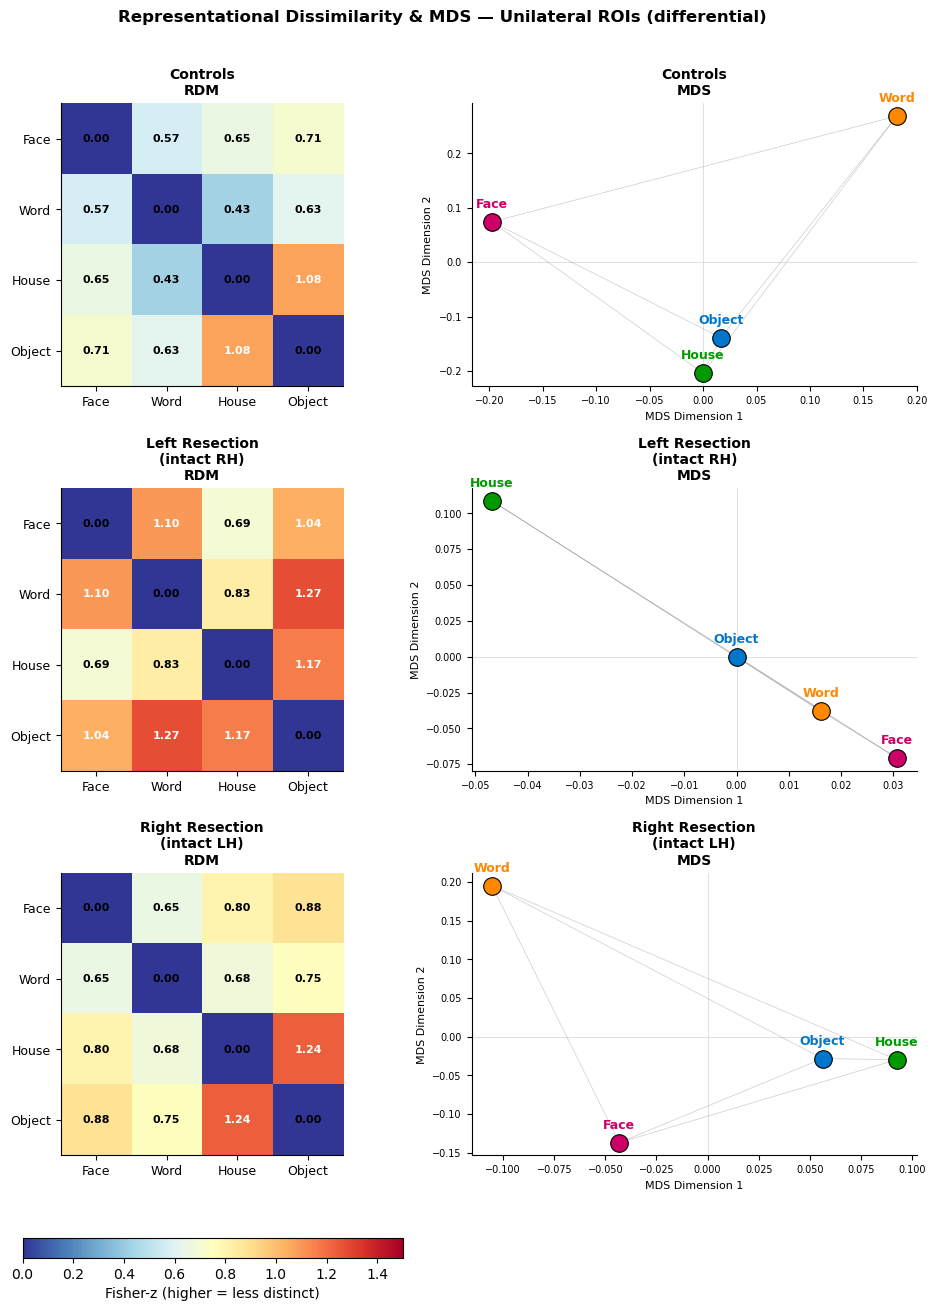

  Saved: fig_rdm_mds_unilateral_differential.png


In [37]:
from sklearn.manifold import MDS
from scipy import stats as sp_stats

# Category colors for MDS points (matching Liu Fig 5)
MDS_COLORS = {
    'face':   '#cc0066',   # magenta
    'word':   '#ff8800',   # orange
    'house':  '#009900',   # green
    'object': '#0077cc',   # blue
}

def fig_rdm_mds(cope_set='differential', roi_type='unilateral'):
    """3-row × 2-col figure: RDM (left) + MDS (right) per group.
    Rows: Controls | OTC Left Resection | OTC Right Resection.
    RDM: mean Fisher-z pairwise similarity (higher = less distinct).
    MDS: 2D embedding of dissimilarity (1 - fisher_z)."""

    pair_file = LIU_DIR / f'pairwise_correlations_{cope_set}.csv'
    if not pair_file.exists():
        print(f'  SKIP: {pair_file} not found')
        return

    df = pd.read_csv(pair_file)

    # First session per subject
    first = df.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    df = df.merge(first, on='subject_id')
    df = df[df['session'] == df['fs']]

    # Assign plot group; intact hemi only for OTC
    df['plot_group'] = df.apply(
        lambda r: f"OTC-{r['surgery_side']}" if r['group'] == 'OTC' else r['group'], axis=1)
    uni = df[df['cat_type'] == roi_type].copy()
    uni = uni[~((uni['group'] == 'OTC') & (uni['hemi_label'] != 'intact'))]

    cats = ['face', 'word', 'house', 'object']

    def get_mean_matrix(subset):
        """Build 4x4 mean Fisher-z matrix for a group subset."""
        mat = np.full((4, 4), np.nan)
        for i, ci in enumerate(cats):
            for j, cj in enumerate(cats):
                if i == j:
                    mat[i, j] = 0.0
                    continue
                for pair_str in [f'{ci}-{cj}', f'{cj}-{ci}']:
                    v = subset[subset['pair'] == pair_str]['fisher_r'].values
                    if len(v) > 0:
                        mat[i, j] = v.mean()
                        break
        return mat

    groups = [
        ('control',   'Controls'),
        ('OTC-left',  'Left Resection\n(intact RH)'),
        ('OTC-right', 'Right Resection\n(intact LH)'),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(10, 13))
    fig.patch.set_facecolor('white')

    for row_idx, (grp, title) in enumerate(groups):
        ax_rdm = axes[row_idx, 0]
        ax_mds = axes[row_idx, 1]

        gd  = uni[uni['plot_group'] == grp]
        mat = get_mean_matrix(gd)

        # ── RDM ──────────────────────────────────────────────────────────────
        im = ax_rdm.imshow(mat, cmap='RdYlBu_r', vmin=0, vmax=1.5, aspect='equal')
        ax_rdm.set_xticks(range(4))
        ax_rdm.set_xticklabels([c.title() for c in cats], fontsize=9)
        ax_rdm.set_yticks(range(4))
        ax_rdm.set_yticklabels([c.title() for c in cats], fontsize=9)
        ax_rdm.set_title(f'{title}\nRDM', fontsize=10, fontweight='bold')

        for i in range(4):
            for j in range(4):
                if np.isnan(mat[i, j]):
                    continue
                txt_col = 'white' if mat[i, j] > 1.0 else 'black'
                ax_rdm.text(j, i, f'{mat[i,j]:.2f}',
                            ha='center', va='center',
                            fontsize=8, color=txt_col, fontweight='bold')

        # ── MDS ──────────────────────────────────────────────────────────────
        # Convert similarity → dissimilarity, symmetrize, zero diagonal
        sim  = mat.copy()
        np.fill_diagonal(sim, 0)
        # Replace any remaining NaN with column mean
        col_means = np.nanmean(sim, axis=0)
        for i in range(4):
            for j in range(4):
                if np.isnan(sim[i, j]):
                    sim[i, j] = (col_means[i] + col_means[j]) / 2
        dissim = np.clip(1 - sim, 0, None)
        dissim = (dissim + dissim.T) / 2   # enforce symmetry
        np.fill_diagonal(dissim, 0)

        mds   = MDS(n_components=2, dissimilarity='precomputed',
                    random_state=42, n_init=10)
        coords = mds.fit_transform(dissim)

        for k, cat in enumerate(cats):
            color = MDS_COLORS[cat]
            ax_mds.scatter(coords[k, 0], coords[k, 1],
                           color=color, s=160, zorder=4,
                           edgecolors='black', linewidth=0.8)
            ax_mds.annotate(cat.title(), (coords[k, 0], coords[k, 1]),
                            fontsize=9, fontweight='bold',
                            ha='center', va='bottom',
                            xytext=(0, 8), textcoords='offset points',
                            color=color)

        # Connect points with lines to show geometry (like Liu Fig 5D)
        for i in range(4):
            for j in range(i + 1, 4):
                ax_mds.plot([coords[i, 0], coords[j, 0]],
                            [coords[i, 1], coords[j, 1]],
                            color='gray', linewidth=0.5, alpha=0.4, zorder=2)

        ax_mds.set_title(f'{title}\nMDS', fontsize=10, fontweight='bold')
        ax_mds.set_xlabel('MDS Dimension 1', fontsize=8)
        ax_mds.set_ylabel('MDS Dimension 2', fontsize=8)
        ax_mds.tick_params(labelsize=7)
        ax_mds.spines[['top', 'right']].set_visible(False)
        ax_mds.axhline(0, color='lightgray', linewidth=0.5, zorder=1)
        ax_mds.axvline(0, color='lightgray', linewidth=0.5, zorder=1)

    # Shared colorbar for RDMs
    cbar_ax = fig.add_axes([0.08, 0.02, 0.38, 0.015])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal',
                 label='Fisher-z (higher = less distinct)')

    plt.suptitle(f'Representational Dissimilarity & MDS — {roi_type.title()} ROIs ({cope_set})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.06, 1, 0.97])
    plt.savefig(str(FIG_DIR / f'fig_rdm_mds_{roi_type}_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_rdm_mds_{roi_type}_{cope_set}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_rdm_mds(COPE_SET)

/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/tmp/ipykernel_3052388/3930876207.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.ti

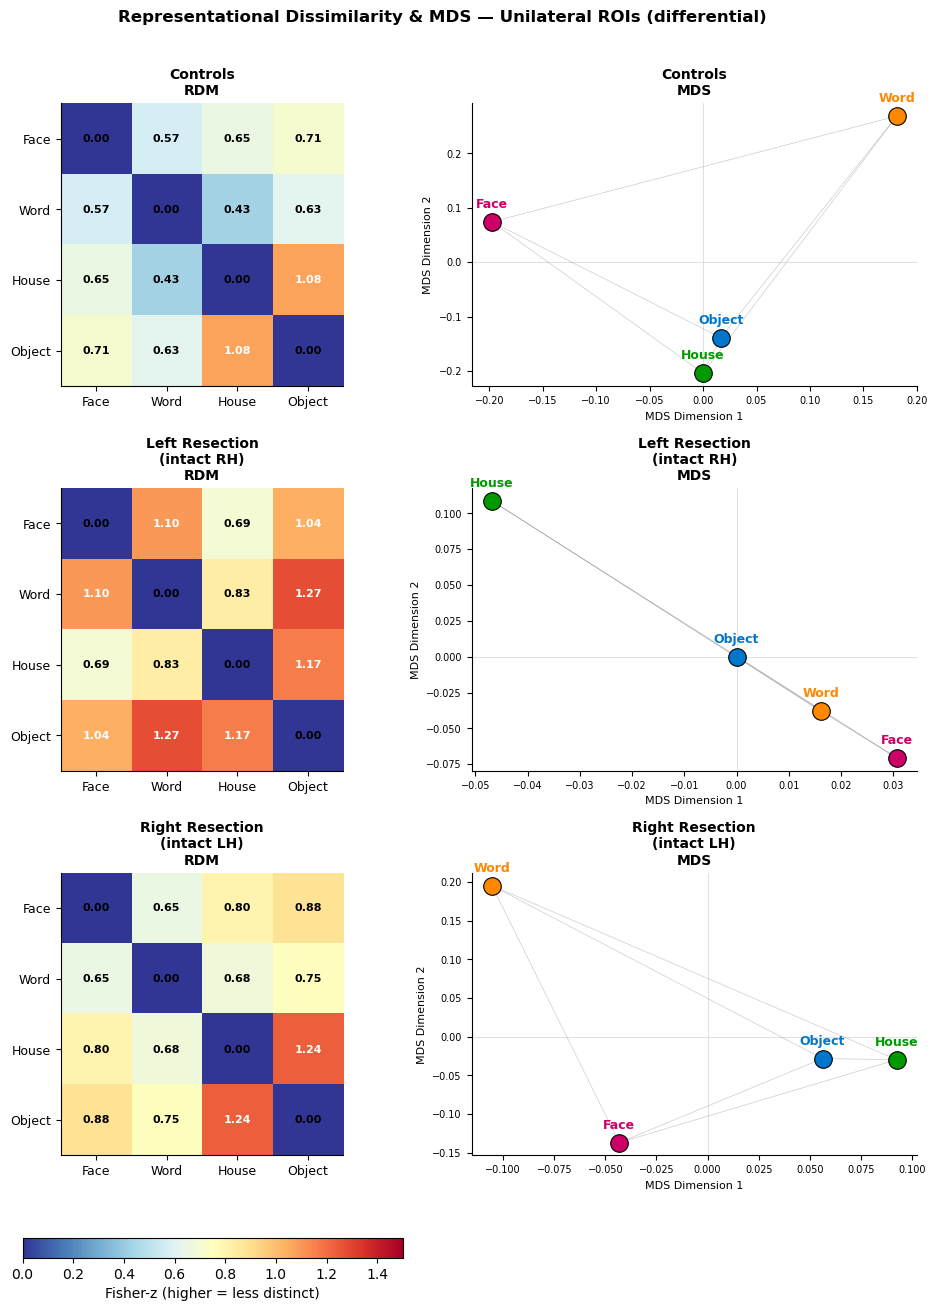

  Saved: fig_rdm_mds_unilateral_differential.png


/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to

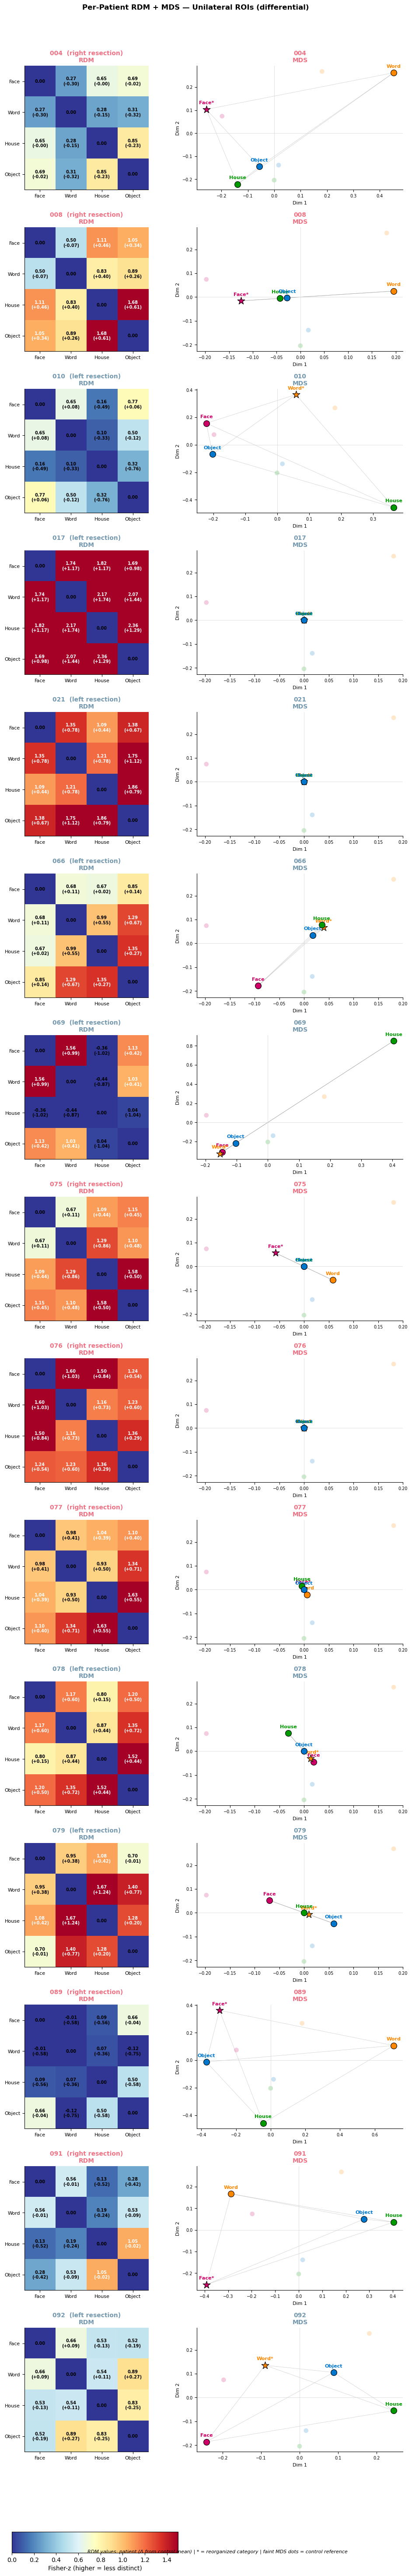

  Saved: fig_rdm_mds_perpatient_unilateral_differential.png


In [39]:
from sklearn.manifold import MDS
from scipy import stats as sp_stats

# Category colors for MDS points (matching Liu Fig 5)
MDS_COLORS = {
    'face':   '#cc0066',   # magenta
    'word':   '#ff8800',   # orange
    'house':  '#009900',   # green
    'object': '#0077cc',   # blue
}

def fig_rdm_mds(cope_set='differential', roi_type='unilateral'):
    """3-row × 2-col figure: RDM (left) + MDS (right) per group.
    Rows: Controls | OTC Left Resection | OTC Right Resection.
    RDM: mean Fisher-z pairwise similarity (higher = less distinct).
    MDS: 2D embedding of dissimilarity (1 - fisher_z)."""

    pair_file = LIU_DIR / f'pairwise_correlations_{cope_set}.csv'
    if not pair_file.exists():
        print(f'  SKIP: {pair_file} not found')
        return

    df = pd.read_csv(pair_file)

    # First session per subject
    first = df.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    df = df.merge(first, on='subject_id')
    df = df[df['session'] == df['fs']]

    # Assign plot group; intact hemi only for OTC
    df['plot_group'] = df.apply(
        lambda r: f"OTC-{r['surgery_side']}" if r['group'] == 'OTC' else r['group'], axis=1)
    uni = df[df['cat_type'] == roi_type].copy()
    uni = uni[~((uni['group'] == 'OTC') & (uni['hemi_label'] != 'intact'))]

    cats = ['face', 'word', 'house', 'object']

    def get_mean_matrix(subset):
        """Build 4x4 mean Fisher-z matrix for a group subset."""
        mat = np.full((4, 4), np.nan)
        for i, ci in enumerate(cats):
            for j, cj in enumerate(cats):
                if i == j:
                    mat[i, j] = 0.0
                    continue
                for pair_str in [f'{ci}-{cj}', f'{cj}-{ci}']:
                    v = subset[subset['pair'] == pair_str]['fisher_r'].values
                    if len(v) > 0:
                        mat[i, j] = v.mean()
                        break
        return mat

    groups = [
        ('control',   'Controls'),
        ('OTC-left',  'Left Resection\n(intact RH)'),
        ('OTC-right', 'Right Resection\n(intact LH)'),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(10, 13))
    fig.patch.set_facecolor('white')

    for row_idx, (grp, title) in enumerate(groups):
        ax_rdm = axes[row_idx, 0]
        ax_mds = axes[row_idx, 1]

        gd  = uni[uni['plot_group'] == grp]
        mat = get_mean_matrix(gd)

        # ── RDM ──────────────────────────────────────────────────────────────
        im = ax_rdm.imshow(mat, cmap='RdYlBu_r', vmin=0, vmax=1.5, aspect='equal')
        ax_rdm.set_xticks(range(4))
        ax_rdm.set_xticklabels([c.title() for c in cats], fontsize=9)
        ax_rdm.set_yticks(range(4))
        ax_rdm.set_yticklabels([c.title() for c in cats], fontsize=9)
        ax_rdm.set_title(f'{title}\nRDM', fontsize=10, fontweight='bold')

        for i in range(4):
            for j in range(4):
                if np.isnan(mat[i, j]):
                    continue
                txt_col = 'white' if mat[i, j] > 1.0 else 'black'
                ax_rdm.text(j, i, f'{mat[i,j]:.2f}',
                            ha='center', va='center',
                            fontsize=8, color=txt_col, fontweight='bold')

        # ── MDS ──────────────────────────────────────────────────────────────
        # Convert similarity → dissimilarity, symmetrize, zero diagonal
        sim  = mat.copy()
        np.fill_diagonal(sim, 0)
        # Replace any remaining NaN with column mean
        col_means = np.nanmean(sim, axis=0)
        for i in range(4):
            for j in range(4):
                if np.isnan(sim[i, j]):
                    sim[i, j] = (col_means[i] + col_means[j]) / 2
        dissim = np.clip(1 - sim, 0, None)
        dissim = (dissim + dissim.T) / 2   # enforce symmetry
        np.fill_diagonal(dissim, 0)

        mds   = MDS(n_components=2, dissimilarity='precomputed',
                    random_state=42, n_init=10)
        coords = mds.fit_transform(dissim)

        for k, cat in enumerate(cats):
            color = MDS_COLORS[cat]
            ax_mds.scatter(coords[k, 0], coords[k, 1],
                           color=color, s=160, zorder=4,
                           edgecolors='black', linewidth=0.8)
            ax_mds.annotate(cat.title(), (coords[k, 0], coords[k, 1]),
                            fontsize=9, fontweight='bold',
                            ha='center', va='bottom',
                            xytext=(0, 8), textcoords='offset points',
                            color=color)

        # Connect points with lines to show geometry (like Liu Fig 5D)
        for i in range(4):
            for j in range(i + 1, 4):
                ax_mds.plot([coords[i, 0], coords[j, 0]],
                            [coords[i, 1], coords[j, 1]],
                            color='gray', linewidth=0.5, alpha=0.4, zorder=2)

        ax_mds.set_title(f'{title}\nMDS', fontsize=10, fontweight='bold')
        ax_mds.set_xlabel('MDS Dimension 1', fontsize=8)
        ax_mds.set_ylabel('MDS Dimension 2', fontsize=8)
        ax_mds.tick_params(labelsize=7)
        ax_mds.spines[['top', 'right']].set_visible(False)
        ax_mds.axhline(0, color='lightgray', linewidth=0.5, zorder=1)
        ax_mds.axvline(0, color='lightgray', linewidth=0.5, zorder=1)

    # Shared colorbar for RDMs
    cbar_ax = fig.add_axes([0.08, 0.02, 0.38, 0.015])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal',
                 label='Fisher-z (higher = less distinct)')

    plt.suptitle(f'Representational Dissimilarity & MDS — {roi_type.title()} ROIs ({cope_set})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.06, 1, 0.97])
    plt.savefig(str(FIG_DIR / f'fig_rdm_mds_{roi_type}_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_rdm_mds_{roi_type}_{cope_set}.png')


def fig_rdm_mds_per_patient(cope_set='differential', roi_type='unilateral'):
    """One row per OTC patient: RDM (left) + MDS (right).
    Control group mean shown as faint reference RDM in title annotation."""

    pair_file = LIU_DIR / f'pairwise_correlations_{cope_set}.csv'
    if not pair_file.exists():
        print(f'  SKIP: {pair_file} not found')
        return

    df = pd.read_csv(pair_file)
    first = df.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    df = df.merge(first, on='subject_id')
    df = df[df['session'] == df['fs']]

    uni = df[df['cat_type'] == roi_type].copy()
    otc = uni[(uni['group'] == 'OTC') & (uni['hemi_label'] == 'intact')].copy()
    ctrl = uni[uni['group'] == 'control'].copy()

    cats = ['face', 'word', 'house', 'object']

    def get_mean_matrix(subset):
        mat = np.full((4, 4), np.nan)
        for i, ci in enumerate(cats):
            for j, cj in enumerate(cats):
                if i == j:
                    mat[i, j] = 0.0; continue
                for ps in [f'{ci}-{cj}', f'{cj}-{ci}']:
                    v = subset[subset['pair'] == ps]['fisher_r'].values
                    if len(v) > 0:
                        mat[i, j] = v.mean(); break
        return mat

    def mat_to_dissim(mat):
        sim = mat.copy(); np.fill_diagonal(sim, 0)
        col_means = np.nanmean(sim, axis=0)
        for i in range(4):
            for j in range(4):
                if np.isnan(sim[i, j]):
                    sim[i, j] = (col_means[i] + col_means[j]) / 2
        d = np.clip(1 - sim, 0, None)
        d = (d + d.T) / 2; np.fill_diagonal(d, 0)
        return d

    ctrl_mat = get_mean_matrix(ctrl)

    patients = sorted(otc['subject'].unique(), key=lambda s: short_name(s))
    n_pts    = len(patients)

    fig, axes = plt.subplots(n_pts, 2, figsize=(10, 4 * n_pts))
    if n_pts == 1:
        axes = axes[np.newaxis, :]

    for row_idx, sub in enumerate(patients):
        ax_rdm = axes[row_idx, 0]
        ax_mds = axes[row_idx, 1]

        sub_data   = otc[otc['subject'] == sub]
        side       = sub_data['surgery_side'].iloc[0]
        lbl        = short_name(sub)
        star_cat   = REORG.get(side, '')
        mat        = get_mean_matrix(sub_data)

        # ── RDM ──────────────────────────────────────────────────────────────
        im = ax_rdm.imshow(mat, cmap='RdYlBu_r', vmin=0, vmax=1.5, aspect='equal')
        ax_rdm.set_xticks(range(4))
        ax_rdm.set_xticklabels([c.title() for c in cats], fontsize=8)
        ax_rdm.set_yticks(range(4))
        ax_rdm.set_yticklabels([c.title() for c in cats], fontsize=8)

        side_col = OTC_L if side == 'left' else OTC_R
        ax_rdm.set_title(f'{lbl}  ({side} resection)\nRDM',
                         fontsize=10, fontweight='bold', color=side_col)

        for i in range(4):
            for j in range(4):
                if np.isnan(mat[i, j]):
                    continue
                # Show delta from control mean in parentheses
                delta    = mat[i, j] - ctrl_mat[i, j] if not np.isnan(ctrl_mat[i, j]) else np.nan
                txt_col  = 'white' if mat[i, j] > 1.0 else 'black'
                delta_str = f'\n({delta:+.2f})' if not np.isnan(delta) and i != j else ''
                ax_rdm.text(j, i, f'{mat[i,j]:.2f}{delta_str}',
                            ha='center', va='center',
                            fontsize=7, color=txt_col, fontweight='bold')

        # ── MDS ──────────────────────────────────────────────────────────────
        dissim = mat_to_dissim(mat)
        mds    = MDS(n_components=2, dissimilarity='precomputed',
                     random_state=42, n_init=10)
        coords = mds.fit_transform(dissim)

        # Faint control MDS as reference
        ctrl_dissim  = mat_to_dissim(ctrl_mat)
        ctrl_coords  = mds.fit_transform(ctrl_dissim)
        for k in range(4):
            ax_mds.scatter(ctrl_coords[k, 0], ctrl_coords[k, 1],
                           color=MDS_COLORS[cats[k]], s=60, alpha=0.2,
                           edgecolors='none', zorder=2)

        for k, cat in enumerate(cats):
            color = MDS_COLORS[cat]
            is_reorg = (cat == star_cat)
            ax_mds.scatter(coords[k, 0], coords[k, 1],
                           color=color, s=160 if is_reorg else 100,
                           marker='*' if is_reorg else 'o',
                           edgecolors='black', linewidth=0.8, zorder=4)
            ax_mds.annotate(f'{cat.title()}{"*" if is_reorg else ""}',
                            (coords[k, 0], coords[k, 1]),
                            fontsize=8, fontweight='bold',
                            ha='center', va='bottom',
                            xytext=(0, 7), textcoords='offset points',
                            color=color)

        for i in range(4):
            for j in range(i + 1, 4):
                ax_mds.plot([coords[i, 0], coords[j, 0]],
                            [coords[i, 1], coords[j, 1]],
                            color='gray', linewidth=0.5, alpha=0.4, zorder=2)

        ax_mds.set_title(f'{lbl}\nMDS', fontsize=10,
                         fontweight='bold', color=side_col)
        ax_mds.set_xlabel('Dim 1', fontsize=8)
        ax_mds.set_ylabel('Dim 2', fontsize=8)
        ax_mds.tick_params(labelsize=7)
        ax_mds.spines[['top', 'right']].set_visible(False)
        ax_mds.axhline(0, color='lightgray', linewidth=0.5)
        ax_mds.axvline(0, color='lightgray', linewidth=0.5)

    # Shared colorbar
    cbar_ax = fig.add_axes([0.08, 0.01, 0.38, 0.008])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal',
                 label='Fisher-z (higher = less distinct)')

    fig.text(0.55, 0.01,
             'RDM values: patient (Δ from control mean) | * = reorganized category | '
             'faint MDS dots = control reference',
             ha='center', fontsize=8, style='italic')

    plt.suptitle(f'Per-Patient RDM + MDS — {roi_type.title()} ROIs ({cope_set})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 0.97])
    plt.savefig(str(FIG_DIR / f'fig_rdm_mds_perpatient_{roi_type}_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_rdm_mds_perpatient_{roi_type}_{cope_set}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_rdm_mds(COPE_SET)
fig_rdm_mds_per_patient(COPE_SET)

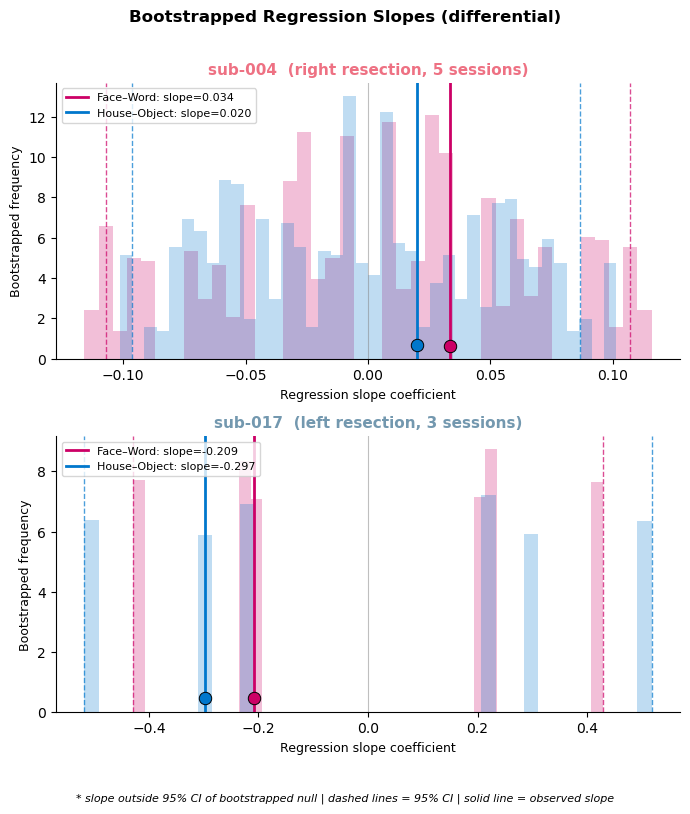

  Saved: fig_bootstrap_slope_differential.png


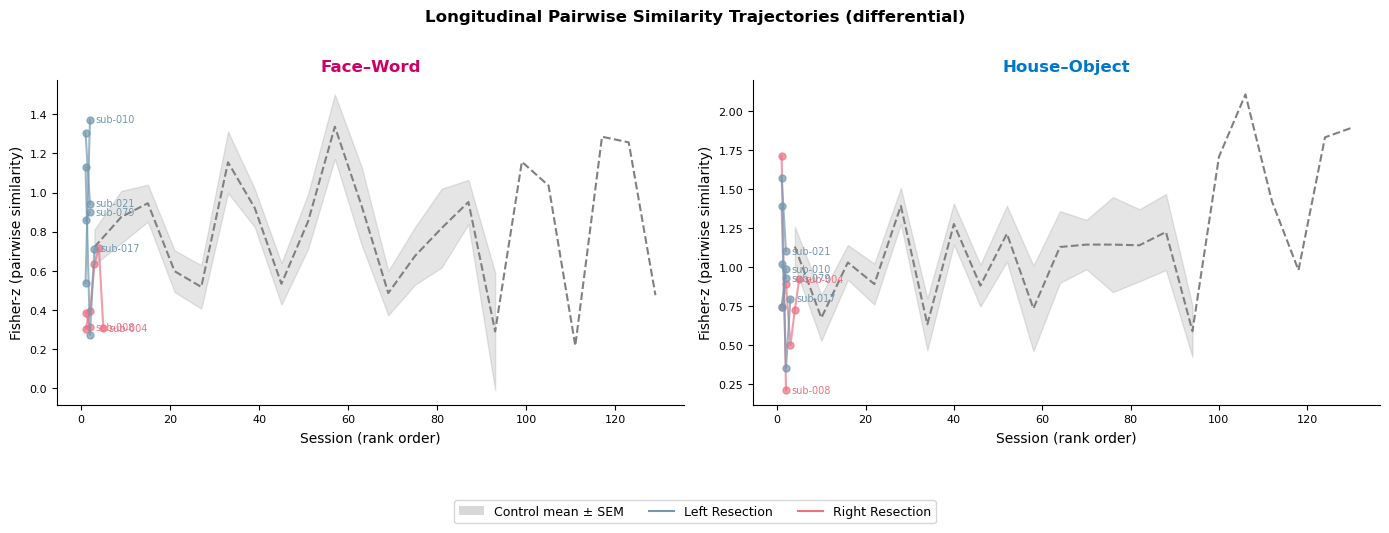

  Saved: fig_longitudinal_trajectories_differential.png


In [41]:
MIN_SESSIONS_BOOTSTRAP = 3  # minimum sessions for bootstrapped regression
MIN_SESSIONS_TRAJECTORY = 2  # minimum sessions to show trajectory

def _get_pairwise_long(cope_set):
    """Load pairwise CSV with all sessions, intact hemi only for OTC."""
    pair_file = LIU_DIR / f'pairwise_correlations_{cope_set}.csv'
    if not pair_file.exists():
        print(f'  SKIP: {pair_file} not found')
        return None
    df = pd.read_csv(pair_file)
    df = df[~((df['group'] == 'OTC') & (df['hemi_label'] != 'intact'))]
    return df


def _session_pair_means(df, subject_id, pairs):
    """Return dict of session → {pair: mean_fisher_r} for a subject."""
    sub = df[df['subject_id'] == subject_id]
    sessions = sorted(sub['session'].unique())
    result = {}
    for ses in sessions:
        ses_data = sub[sub['session'] == ses]
        result[ses] = {}
        for pair in pairs:
            ci, cj = pair.split('-')
            for ps in [f'{ci}-{cj}', f'{cj}-{ci}']:
                v = ses_data[ses_data['pair'] == ps]['fisher_r'].values
                if len(v) > 0:
                    result[ses][pair] = float(v.mean())
                    break
    return result


def _bootstrap_slope(values, n_iter=1000, rng_seed=42):
    """Bootstrap null distribution of regression slopes by shuffling session labels."""
    rng    = np.random.default_rng(rng_seed)
    values = np.array(values)
    n      = len(values)
    x      = np.arange(n)
    slopes = []
    for _ in range(n_iter):
        perm  = rng.permutation(values)
        slope = np.polyfit(x, perm, 1)[0]
        slopes.append(slope)
    observed = np.polyfit(x, values, 1)[0]
    return observed, np.array(slopes)


# ── FIGURE A: Per-patient bootstrapped regression (≥3 sessions) ───────────────

def fig_bootstrapped_slope(cope_set='differential', n_iter=1000):
    """Liu Fig 5E/J/O: bootstrapped regression slope for face-word and
    house-object pairwise dissimilarity over sessions.
    Only includes patients with ≥3 sessions."""
    df = _get_pairwise_long(cope_set)
    if df is None:
        return

    eligible = (df[df['group'] == 'OTC']
                .groupby('subject_id')['session']
                .nunique()
                .loc[lambda x: x >= MIN_SESSIONS_BOOTSTRAP]
                .index.tolist())

    if not eligible:
        print('  No patients with ≥3 sessions — skipping bootstrapped slope figure')
        return

    n_pts = len(eligible)
    fig, axes = plt.subplots(n_pts, 1, figsize=(7, 4 * n_pts), squeeze=False)

    for row_idx, sub_id in enumerate(sorted(eligible)):
        ax   = axes[row_idx, 0]
        lbl  = short_name(sub_id)
        side = df[df['subject_id'] == sub_id]['surgery_side'].iloc[0]
        col  = OTC_L if side == 'left' else OTC_R

        sess_data = _session_pair_means(df, sub_id,
                                        ['face-word', 'house-object'])
        sessions  = sorted(sess_data.keys())
        fw_vals   = [sess_data[s].get('face-word', np.nan) for s in sessions]
        ho_vals   = [sess_data[s].get('house-object', np.nan) for s in sessions]

        for vals, color, pair_label in [
            (fw_vals, '#cc0066', 'Face–Word'),
            (ho_vals, '#0077cc', 'House–Object'),
        ]:
            clean = [(i, v) for i, v in enumerate(vals) if not np.isnan(v)]
            if len(clean) < 3:
                continue
            xs, ys = zip(*clean)
            obs_slope, boot_slopes = _bootstrap_slope(list(ys), n_iter=n_iter)
            ci_lo, ci_hi = np.percentile(boot_slopes, [2.5, 97.5])
            sig = obs_slope < ci_lo or obs_slope > ci_hi

            # Bootstrap histogram
            ax.hist(boot_slopes, bins=40, color=color, alpha=0.25,
                    density=True, zorder=1)
            ax.axvline(ci_lo, color=color, linewidth=1.0,
                       linestyle='--', alpha=0.7)
            ax.axvline(ci_hi, color=color, linewidth=1.0,
                       linestyle='--', alpha=0.7)
            ax.axvline(obs_slope, color=color, linewidth=2.0,
                       linestyle='-', zorder=5,
                       label=f'{pair_label}: slope={obs_slope:.3f}{"*" if sig else ""}')
            ax.scatter([obs_slope], [ax.get_ylim()[1] * 0.05],
                       color=color, s=80, marker='o',
                       edgecolors='black', linewidth=0.7, zorder=6)

        ax.axvline(0, color='gray', linewidth=0.8, linestyle='-', alpha=0.5)
        ax.set_xlabel('Regression slope coefficient', fontsize=9)
        ax.set_ylabel('Bootstrapped frequency', fontsize=9)
        ax.set_title(f'{lbl}  ({side} resection, {len(sessions)} sessions)',
                     fontsize=11, fontweight='bold', color=col)
        ax.legend(fontsize=8, loc='upper left')
        ax.spines[['top', 'right']].set_visible(False)

    fig.text(0.5, -0.01,
             '* slope outside 95% CI of bootstrapped null | '
             'dashed lines = 95% CI | solid line = observed slope',
             ha='center', fontsize=8, style='italic')
    plt.suptitle(f'Bootstrapped Regression Slopes ({cope_set})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.savefig(str(FIG_DIR / f'fig_bootstrap_slope_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_bootstrap_slope_{cope_set}.png')


# ── FIGURE B: Longitudinal distinctiveness trajectories (≥2 sessions) ─────────

def fig_longitudinal_trajectories(cope_set='differential'):
    """Line plot of face-word and house-object pairwise Fisher-z over sessions
    for all OTC patients with ≥2 sessions. One panel per pair."""
    df = _get_pairwise_long(cope_set)
    if df is None:
        return

    eligible = (df[df['group'] == 'OTC']
                .groupby('subject_id')['session']
                .nunique()
                .loc[lambda x: x >= MIN_SESSIONS_TRAJECTORY]
                .index.tolist())

    # Control mean ± SEM per session rank (session 1 = first available)
    ctrl = df[df['group'] == 'control'].copy()
    ctrl['ses_rank'] = ctrl.groupby('subject_id')['session'].rank(method='first').astype(int)

    pairs      = ['face-word', 'house-object']
    pair_colors = {'face-word': '#cc0066', 'house-object': '#0077cc'}
    pair_labels = {'face-word': 'Face–Word', 'house-object': 'House–Object'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for ax, pair in zip(axes, pairs):
        ci, cj = pair.split('-')

        # Control reference band
        ctrl_pair = pd.concat([
            ctrl[ctrl['pair'] == f'{ci}-{cj}'],
            ctrl[ctrl['pair'] == f'{cj}-{ci}']
        ])
        if len(ctrl_pair) > 0:
            ctrl_grp = ctrl_pair.groupby('ses_rank')['fisher_r']
            ctrl_mean = ctrl_grp.mean()
            ctrl_sem  = ctrl_grp.sem()
            ax.fill_between(ctrl_mean.index,
                            ctrl_mean - ctrl_sem,
                            ctrl_mean + ctrl_sem,
                            color='gray', alpha=0.2, zorder=1,
                            label='Control mean ± SEM')
            ax.plot(ctrl_mean.index, ctrl_mean.values,
                    color='gray', linewidth=1.5, linestyle='--', zorder=2)

        # Patient trajectories
        for sub_id in sorted(eligible):
            sub_df   = df[df['subject_id'] == sub_id].copy()
            side     = sub_df['surgery_side'].iloc[0]
            col      = OTC_L if side == 'left' else OTC_R
            lbl      = short_name(sub_id)
            sessions = sorted(sub_df['session'].unique())

            vals = []
            for ses in sessions:
                ses_data = sub_df[sub_df['session'] == ses]
                v = pd.concat([
                    ses_data[ses_data['pair'] == f'{ci}-{cj}'],
                    ses_data[ses_data['pair'] == f'{cj}-{ci}']
                ])['fisher_r'].values
                vals.append(float(v.mean()) if len(v) > 0 else np.nan)

            xs = list(range(1, len(sessions) + 1))
            clean = [(x, v) for x, v in zip(xs, vals) if not np.isnan(v)]
            if len(clean) < 2:
                continue
            cxs, cvs = zip(*clean)
            ax.plot(cxs, cvs, color=col, linewidth=1.5,
                    alpha=0.7, zorder=3, marker='o', markersize=5)
            ax.annotate(lbl, (cxs[-1], cvs[-1]),
                        fontsize=7, color=col,
                        xytext=(4, 0), textcoords='offset points', va='center')

        ax.set_xlabel('Session (rank order)', fontsize=10)
        ax.set_ylabel('Fisher-z (pairwise similarity)', fontsize=10)
        ax.set_title(pair_labels[pair], fontsize=12, fontweight='bold',
                     color=pair_colors[pair])
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)

    legend_elements = [
        Patch(facecolor='gray', alpha=0.3, label='Control mean ± SEM'),
        plt.Line2D([0], [0], color=OTC_L, linewidth=1.5, label='Left Resection'),
        plt.Line2D([0], [0], color=OTC_R, linewidth=1.5, label='Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.06))

    plt.suptitle(f'Longitudinal Pairwise Similarity Trajectories ({cope_set})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 0.97])
    plt.savefig(str(FIG_DIR / f'fig_longitudinal_trajectories_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_longitudinal_trajectories_{cope_set}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_bootstrapped_slope(COPE_SET)
fig_longitudinal_trajectories(COPE_SET)

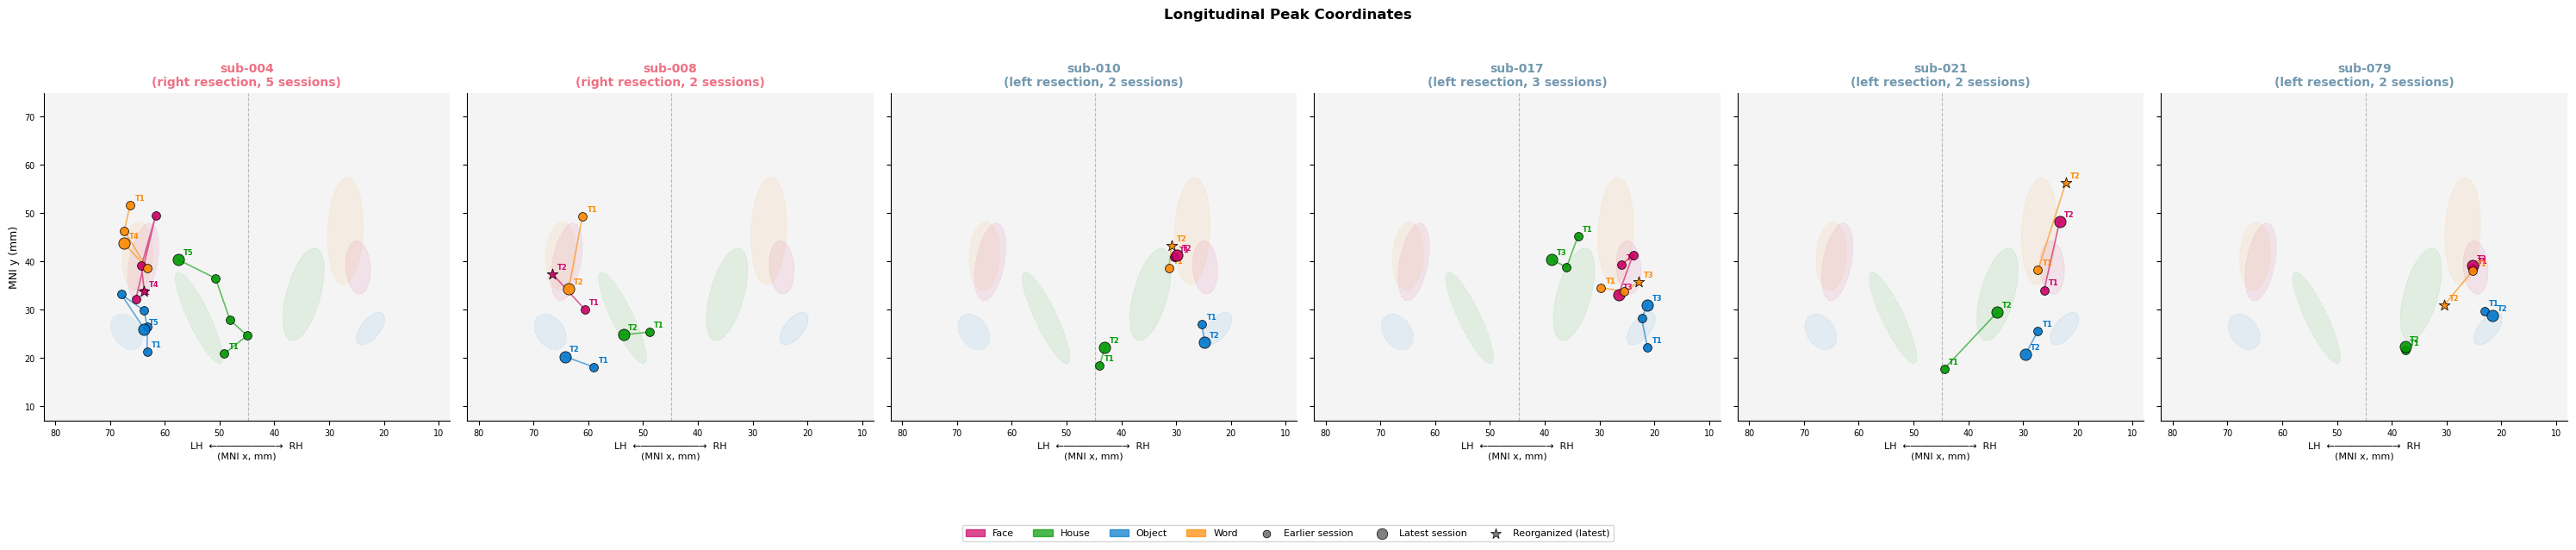

  Saved: fig_longitudinal_spatial.png


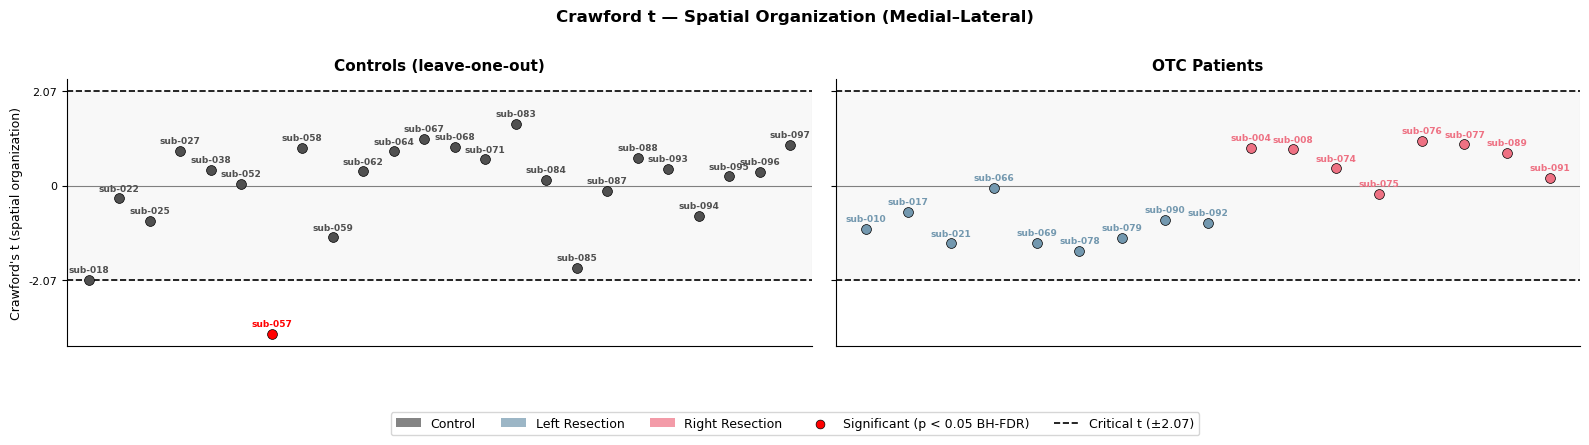

  Saved: fig_crawford_spatial.png


In [45]:
from scipy import stats as sp_stats

MIN_SESSIONS_LONG = 2

# ── FIGURE 4A–C equivalent: longitudinal peak coordinate scatter ──────────────

def fig_longitudinal_spatial(suffix=''):
    """One panel per longitudinal patient (≥2 sessions): peak MNI coordinates
    per session, color-coded by category, connected across sessions."""

    pk_file = Path(f'{processed_dir}/group_results/peak_coords/peak_coords{suffix}.csv')
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)

    # OTC intact hemi only
    otc = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')
    otc = otc[((otc['intact_hemi'] == 'left')  & (otc['hemi'] == 'left')) |
              ((otc['intact_hemi'] == 'right') & (otc['hemi'] == 'right'))]

    # Patients with ≥2 sessions
    n_ses = otc.groupby('sub')['ses_int'].nunique()
    eligible = n_ses[n_ses >= MIN_SESSIONS_LONG].index.tolist()
    eligible = sorted(eligible)

    # Control 1-SD ellipses (all sessions pooled)
    ctrl = df[df['group'] == 'control'].copy()

    # Empirical midline
    lx = ctrl[ctrl['hemi'] == 'left']['peak_x_mni'].mean()
    rx = ctrl[ctrl['hemi'] == 'right']['peak_x_mni'].mean()
    midline_x = (lx + rx) / 2

    pad  = 10
    xlim = (ctrl['peak_x_mni'].min() - pad, ctrl['peak_x_mni'].max() + pad)
    ylim = (ctrl['peak_y_mni'].min() - pad, ctrl['peak_y_mni'].max() + pad)

    n_pts = len(eligible)
    fig, axes = plt.subplots(1, n_pts, figsize=(5 * n_pts, 6), sharey=True)
    if n_pts == 1:
        axes = [axes]
    fig.patch.set_facecolor('white')

    for ax_idx, sub in enumerate(eligible):
        ax      = axes[ax_idx]
        ax.set_facecolor('#f4f4f4')
        sub_df  = otc[otc['sub'] == sub].sort_values('ses_int')
        side    = sub_df['surgery_side'].iloc[0]
        col     = OTC_L if side == 'left' else OTC_R
        lbl     = short_name(sub)
        sessions = sorted(sub_df['ses_int'].unique())

        # Faint control ellipses as reference
        for cat in CATEGORIES:
            color = CAT_COLORS[cat]
            for hemi, ls in [('left', '--'), ('right', '-')]:
                hdat = ctrl[(ctrl['category'] == cat) &
                            (ctrl['hemi'] == hemi)].dropna(
                                subset=['peak_x_mni', 'peak_y_mni'])
                cx, cy = hdat['peak_x_mni'].values, hdat['peak_y_mni'].values
                if len(cx) >= 3:
                    _confidence_ellipse(cx, cy, ax, n_std=1.0,
                                        facecolor=color, alpha=0.07,
                                        edgecolor=color, linewidth=0.8,
                                        linestyle=ls, zorder=1)

        # Per-category trajectories across sessions
        for cat in CATEGORIES:
            color   = CAT_COLORS[cat]
            cat_df  = sub_df[sub_df['category'] == cat].sort_values('ses_int')
            xs      = cat_df['peak_x_mni'].values
            ys      = cat_df['peak_y_mni'].values
            ses_ids = cat_df['ses_int'].values

            if len(xs) < 1:
                continue

            # Connect sessions with line
            if len(xs) > 1:
                ax.plot(xs, ys, color=color, linewidth=1.2,
                        alpha=0.6, zorder=3)

            # Dots per session — size and label encode session number
            for i, (x, y, s) in enumerate(zip(xs, ys, ses_ids)):
                is_first = (i == 0)
                is_last  = (i == len(xs) - 1)
                ax.scatter(x, y, color=color,
                           s=90 if is_last else 50,
                           marker='*' if (REORG.get(side) == cat and is_last) else 'o',
                           edgecolors='black', linewidth=0.6,
                           alpha=0.9, zorder=4)
                # Label session number on first and last
                if is_first or is_last:
                    ax.annotate(f'T{i+1}', (x, y),
                                fontsize=6, color=color,
                                xytext=(4, 4), textcoords='offset points',
                                fontweight='bold')

        ax.axvline(midline_x, color='gray', linewidth=0.8,
                   linestyle='--', alpha=0.5)
        ax.set_xlim(xlim); ax.invert_xaxis()
        ax.set_ylim(ylim)
        ax.set_xlabel('LH  ←──────────→  RH\n(MNI x, mm)', fontsize=8)
        if ax_idx == 0:
            ax.set_ylabel('MNI y (mm)', fontsize=9)
        ax.set_title(f'{lbl}\n({side} resection, {len(sessions)} sessions)',
                     fontsize=10, fontweight='bold', color=col)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)

    legend_cats = [Patch(facecolor=CAT_COLORS[c], alpha=0.7,
                         edgecolor=CAT_COLORS[c], label=c.title())
                   for c in CATEGORIES]
    legend_extra = [
        plt.scatter([], [], color='gray', marker='o', s=40,
                    edgecolors='black', linewidth=0.5, label='Earlier session'),
        plt.scatter([], [], color='gray', marker='o', s=80,
                    edgecolors='black', linewidth=0.5, label='Latest session'),
        plt.scatter([], [], color='gray', marker='*', s=80,
                    edgecolors='black', linewidth=0.5, label='Reorganized (latest)'),
    ]
    fig.legend(handles=legend_cats + legend_extra,
               loc='lower center', ncol=7, fontsize=8,
               frameon=True, bbox_to_anchor=(0.5, -0.06))

    suf_label = f' [{suffix[1:]}]' if suffix else ''
    plt.suptitle(f'Longitudinal Peak Coordinates{suf_label}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_longitudinal_spatial{suffix}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_longitudinal_spatial{suffix}.png')


# ── FIGURE 2I/J equivalent: Crawford t for spatial organization ───────────────

def fig_crawford_spatial(suffix=''):
    """Crawford t-scores for spatial organization (medial-lateral x-coordinate
    correlation with control mean), both controls (LOO) and patients."""

    pk_file = Path(f'{processed_dir}/group_results/peak_coords/peak_coords{suffix}.csv')
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)

    # First session only
    first = df.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'fs'})
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()
    otc  = otc[((otc['intact_hemi'] == 'left')  & (otc['hemi'] == 'left')) |
               ((otc['intact_hemi'] == 'right') & (otc['hemi'] == 'right'))]

    def spatial_corr(sub_df, ref_mean):
        """Correlate subject's x-coords with control mean x-coords."""
        # Take mean per category in case of duplicates
        sub_mean    = sub_df.groupby('category')['peak_x_mni'].mean()
        cats_shared = sorted(set(sub_mean.index) & set(ref_mean.index))
        if len(cats_shared) < 3:
            return np.nan
        sub_x = sub_mean.loc[cats_shared].values
        ref_x = ref_mean.loc[cats_shared].values
        r, _  = sp_stats.pearsonr(sub_x, ref_x)
        return float(r)

    # Control mean x per category (preferred hemi)
    ctrl_mean_x = (ctrl.groupby('category')['peak_x_mni'].mean())

    # Fisher-z transform helper
    def fz(r):
        return 0.5 * np.log((1 + np.clip(r, -0.999, 0.999)) /
                             (1 - np.clip(r, -0.999, 0.999)))

    # ── Controls: leave-one-out ───────────────────────────────────────────────
    ctrl_subs = sorted(ctrl['sub'].unique())
    ctrl_corrs = {}
    for sub in ctrl_subs:
        sub_df   = ctrl[ctrl['sub'] == sub]
        loo_mean = ctrl[ctrl['sub'] != sub].groupby('category')['peak_x_mni'].mean()
        r        = spatial_corr(sub_df, loo_mean)
        ctrl_corrs[sub] = fz(r) if not np.isnan(r) else np.nan

    ctrl_fz = np.array([v for v in ctrl_corrs.values() if not np.isnan(v)])
    n_ctrl  = len(ctrl_fz)
    t_crit  = sp_stats.t.ppf(0.975, df=n_ctrl - 2)

    # LOO Crawford t for each control
    ctrl_t = {}
    for sub in ctrl_subs:
        val = ctrl_corrs.get(sub, np.nan)
        if np.isnan(val):
            continue
        loo = np.array([v for s, v in ctrl_corrs.items()
                        if s != sub and not np.isnan(v)])
        t, _, _ = crawford_t(val, loo)
        ctrl_t[sub] = t

    # ── Patients ──────────────────────────────────────────────────────────────
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')
    otc_subs  = sorted(otc['sub'].unique(),
                       key=lambda s: otc[otc['sub'] == s]['surgery_side'].iloc[0])
    otc_t     = {}
    otc_sides = {}
    for sub in otc_subs:
        sub_df = otc[otc['sub'] == sub]
        r      = spatial_corr(sub_df, ctrl_mean_x)
        fz_val = fz(r) if not np.isnan(r) else np.nan
        t, _, _ = crawford_t(fz_val, ctrl_fz) if not np.isnan(fz_val) else (np.nan, np.nan, 0)
        otc_t[sub]     = t
        otc_sides[sub] = sub_df['surgery_side'].iloc[0]

    # BH-FDR on patient t-scores
    pt_subs   = [s for s in otc_subs if not np.isnan(otc_t.get(s, np.nan))]
    pt_pvals  = []
    for s in pt_subs:
        t = otc_t[s]
        p = 2 * sp_stats.t.sf(abs(t), df=n_ctrl - 1)
        pt_pvals.append(p)
    pt_sig = _bh_fdr(np.array(pt_pvals)) if pt_pvals else []
    pt_sig_map = {s: sig for s, sig in zip(pt_subs, pt_sig)}

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

    for ax, (subs, t_dict, title, is_ctrl) in zip(axes, [
        (ctrl_subs, ctrl_t, 'Controls (leave-one-out)', True),
        (otc_subs,  otc_t,  'OTC Patients',             False),
    ]):
        ax.axhline(0,       color='gray',  linewidth=0.8, zorder=1)
        ax.axhline( t_crit, color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhline(-t_crit, color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhspan(-t_crit, t_crit, alpha=0.05, color='gray', zorder=0)

        for x_idx, sub in enumerate(subs):
            t = t_dict.get(sub, np.nan)
            if np.isnan(t):
                continue
            if is_ctrl:
                col       = CTRL_R
                dot_color = 'red' if abs(t) > t_crit else col
            else:
                side      = otc_sides[sub]
                col       = OTC_L if side == 'left' else OTC_R
                dot_color = 'red' if pt_sig_map.get(sub, False) else col

            ax.scatter(x_idx + 1, t, color=dot_color, s=50,
                       edgecolors='black', linewidth=0.5, zorder=4)
            ax.annotate(short_name(sub), (x_idx + 1, t),
                        fontsize=6.5, fontweight='bold',
                        ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points',
                        color=dot_color)

        ax.set_xlim(0.3, len(subs) + 0.7)
        ax.set_xticks([])
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)

    axes[0].set_ylabel("Crawford's t (spatial organization)", fontsize=9)
    axes[0].set_yticks([-t_crit, 0, t_crit])
    axes[0].set_yticklabels([f'{-t_crit:.2f}', '0', f'{t_crit:.2f}'], fontsize=8)

    legend_elements = [
        Patch(facecolor=CTRL_R, alpha=0.7, label='Control'),
        Patch(facecolor=OTC_L,  alpha=0.7, label='Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.7, label='Right Resection'),
        plt.scatter([], [], color='red', s=40, edgecolors='black',
                    linewidth=0.5, label='Significant (p < 0.05 BH-FDR)'),
        plt.Line2D([0], [0], color='black', linewidth=1.2, linestyle='--',
                   label=f'Critical t (±{t_crit:.2f})'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=5,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.1))

    plt.suptitle('Crawford t — Spatial Organization (Medial–Lateral)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.97])
    plt.savefig(str(FIG_DIR / f'fig_crawford_spatial{suffix}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_crawford_spatial{suffix}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_longitudinal_spatial()
fig_crawford_spatial()

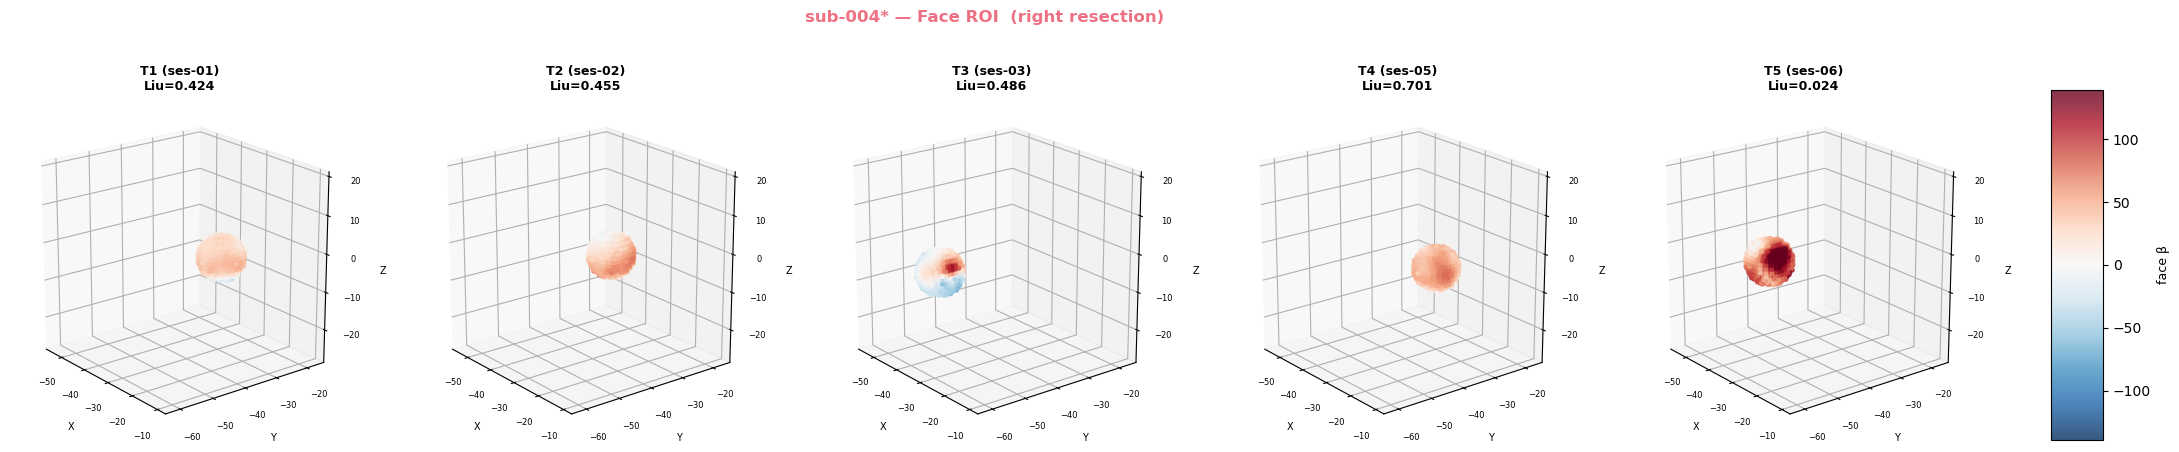

  Saved: fig_roi3d_sub-004_face.png


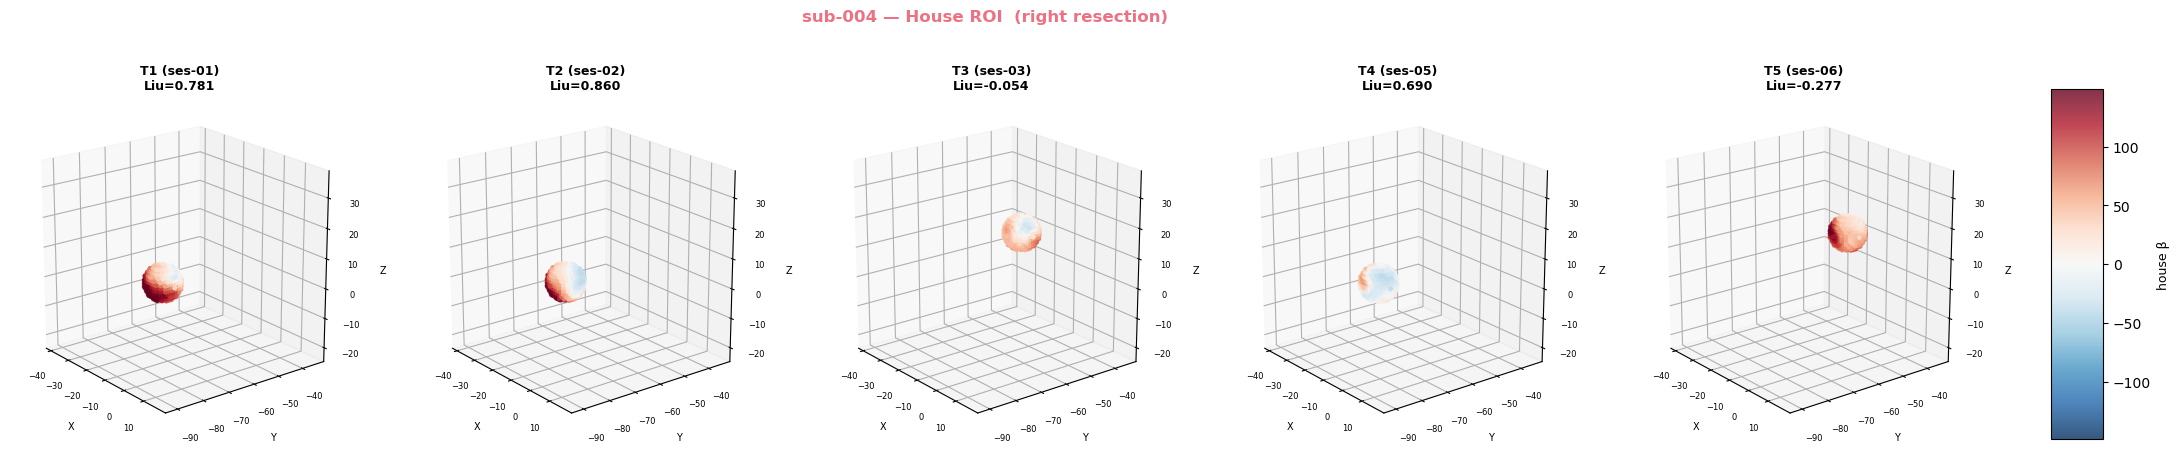

  Saved: fig_roi3d_sub-004_house.png


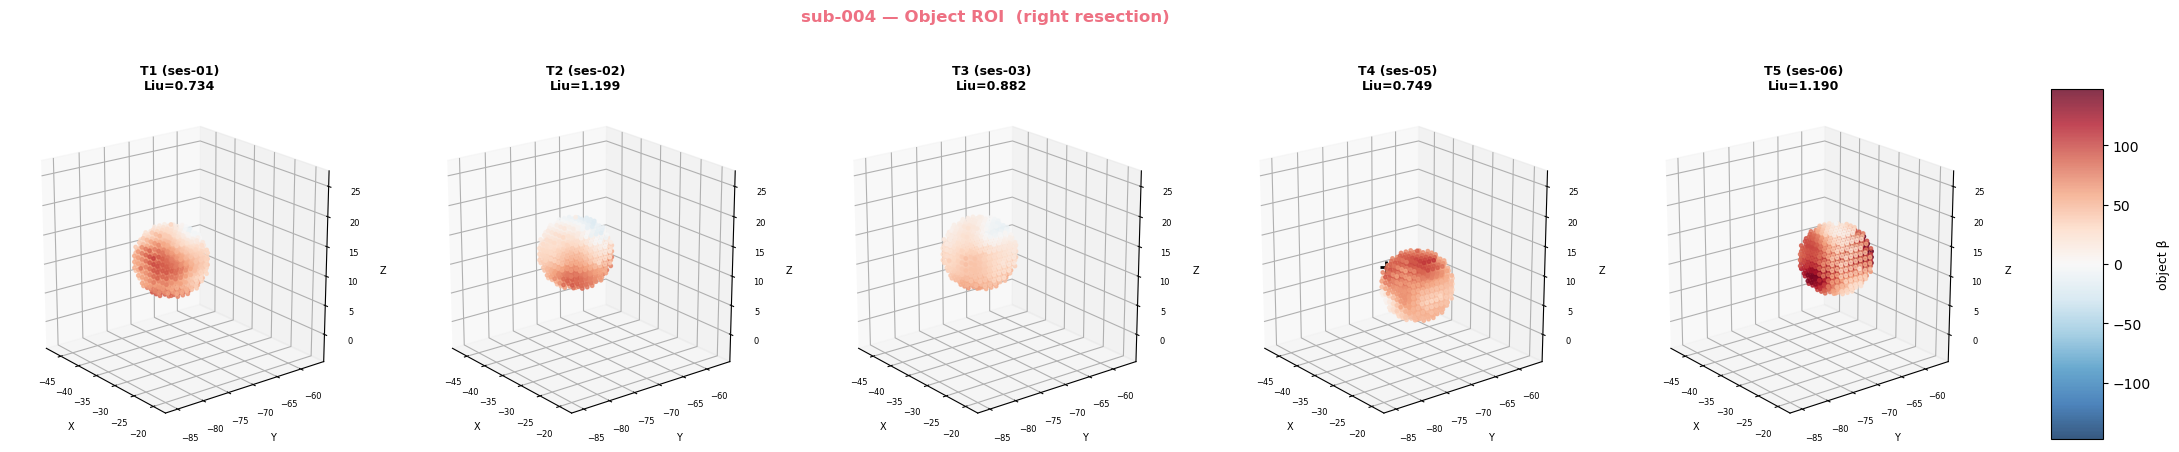

  Saved: fig_roi3d_sub-004_object.png


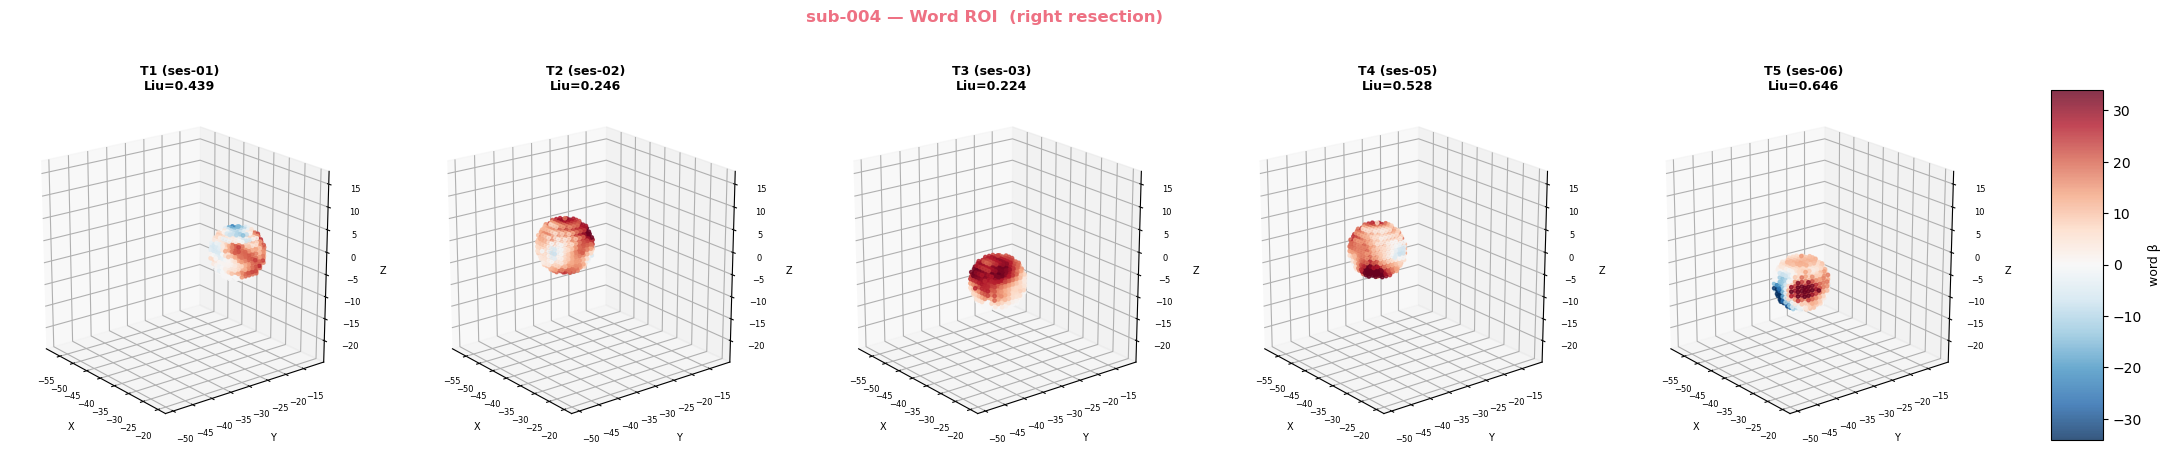

  Saved: fig_roi3d_sub-004_word.png


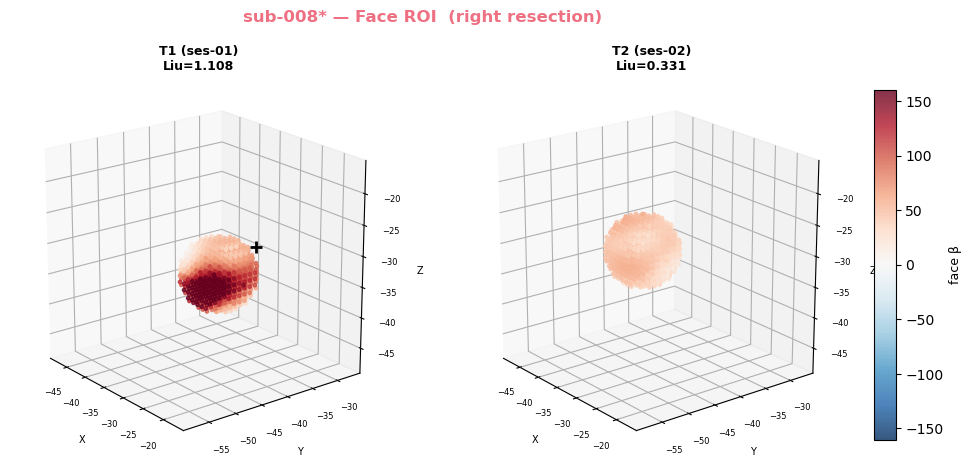

  Saved: fig_roi3d_sub-008_face.png


KeyboardInterrupt: 

In [46]:
import nibabel as nib
from scipy.ndimage import label, center_of_mass
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

# ── Config (mirrors 08_liu_distinctiveness.py) ────────────────────────────────
_THRESH_Z   = 1.96
_TOP_PCT    = 0.10
_MIN_VOX    = 50
_SPHERE_R   = 6
_RSA_COPES  = {'face': 15, 'house': 16, 'object': 17, 'word': 18}
_LOC_COPES  = {'face': 1,  'house': 2,  'object': 3,  'word': 4}
_CACHE_3D   = {}

def _load_nii(fp):
    k = str(fp)
    if k not in _CACHE_3D:
        _CACHE_3D[k] = nib.load(k)
    return _CACHE_3D[k]


def _get_roi_data(sub_id, ses, category, hemi, base_dir):
    """Load sphere betas + world coords for one subject/session/category/hemi.
    Returns dict with keys: world_coords, preferred_betas, centroid,
    liu_distinctiveness, n_voxels — or None if ROI not found."""
    sub_clean   = sub_id.replace('sub-', '')
    first_ses   = sorted(Path(base_dir / sub_id).glob('ses-*/anat/T1w_brain_mask.nii.gz'))
    if not first_ses:
        return None
    first_ses = first_ses[0].parts[-3].replace('ses-', '')

    anat_dir  = base_dir / sub_id / f'ses-{first_ses}' / 'anat'
    bm_file   = anat_dir / 'T1w_brain_mask.nii.gz'
    bm        = _load_nii(bm_file).get_fdata() > 0 if bm_file.exists() else None

    # Searchmask
    mask_img = None
    for sd in ['ROIs', f'derivatives/rois']:
        p = base_dir / sub_id / f'ses-{first_ses}' / sd / f'{hemi}_{category}_searchmask.nii.gz'
        if p.exists():
            mask_img = _load_nii(p); break
    if mask_img is None:
        return None

    mask    = mask_img.get_fdata() > 0
    affine  = mask_img.affine
    shape   = mask_img.shape

    # Zstat for localisation
    feat  = base_dir / sub_id / f'ses-{ses}' / 'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat'
    zname = 'zstat1.nii.gz' if ses == first_ses else f'zstat1_ses{first_ses}.nii.gz'
    zf    = feat / f'cope{_LOC_COPES[category]}.feat' / 'stats' / zname
    if not zf.exists():
        return None

    z = _load_nii(zf).get_fdata().copy()
    if bm is not None:
        z[~bm] = 0

    supra = (z > _THRESH_Z) & mask
    if supra.sum() < _MIN_VOX:
        return None

    top_n = max(_MIN_VOX, int(supra.sum() * _TOP_PCT))
    thresh = np.sort(z[supra])[-top_n]
    top    = (z >= thresh) & supra
    labeled, nc = label(top)
    if nc == 0:
        return None

    li   = np.argmax([(labeled == i).sum() for i in range(1, nc + 1)]) + 1
    roi  = (labeled == li)
    pidx = np.unravel_index(np.argmax(z * roi), z.shape)
    peak = nib.affines.apply_affine(affine, np.array(pidx))
    cent = nib.affines.apply_affine(affine, np.array(center_of_mass(roi)))

    # Sphere around peak
    grid  = np.array(np.meshgrid(*[np.arange(s) for s in shape],
                                  indexing='ij')).reshape(3, -1).T
    world = nib.affines.apply_affine(affine, grid)
    dists = np.linalg.norm(world - peak, axis=1)
    sphere_mask = np.zeros(shape, dtype=bool)
    for c in grid[dists <= _SPHERE_R]:
        sphere_mask[c[0], c[1], c[2]] = True

    # Beta patterns in sphere
    cname = 'cope1.nii.gz' if ses == first_ses else f'cope1_ses{first_ses}.nii.gz'
    patterns, vcats = [], []
    for cat in ['face', 'house', 'object', 'word']:
        cf = feat / f'cope{_RSA_COPES[cat]}.feat' / 'stats' / cname
        if not cf.exists():
            continue
        b = _load_nii(cf).get_fdata()[sphere_mask]
        b = b[np.isfinite(b)]
        if len(b) > 0:
            patterns.append(b); vcats.append(cat)

    if len(patterns) < 2 or category not in vcats:
        return None

    min_v   = min(len(b) for b in patterns)
    bmat    = np.column_stack([b[:min_v] for b in patterns])
    pref_i  = vcats.index(category)
    pref_b  = bmat[:, pref_i]

    # World coords of sphere voxels
    sphere_coords = nib.affines.apply_affine(affine, grid[dists <= _SPHERE_R])

    # Liu distinctiveness
    corr   = np.corrcoef(bmat.T)
    fisher = np.arctanh(np.clip(corr, -0.999, 0.999))
    nonp   = [i for i in range(len(vcats)) if i != pref_i]
    liu    = float(np.mean(fisher[pref_i, nonp]))

    return {
        'world_coords':       sphere_coords,
        'preferred_betas':    pref_b,
        'centroid':           cent,
        'liu_distinctiveness': liu,
        'n_voxels':           int(sphere_mask.sum()),
    }


def fig_voxel_roi_3d(categories=None, min_sessions=2, suffix=''):
    """Liu Fig 5A/F/K: 3D scatter of sphere voxels coloured by preferred-category
    beta value, one panel per session, one figure per patient × category.
    Only longitudinal patients (≥ min_sessions) are plotted."""

    from sym_pt_params import processed_dir, get_sessions, get_sub_info, is_patient, _load_csv

    if categories is None:
        categories = CATEGORIES

    base_dir = Path(processed_dir)
    sub_csv  = _load_csv()

    # Identify longitudinal OTC subjects
    pk = pd.read_csv(base_dir / 'group_results/peak_coords/peak_coords.csv')
    n_ses = pk[pk['group'] == 'OTC'].groupby('sub')['ses'].nunique()
    long_subs = n_ses[n_ses >= min_sessions].index.tolist()

    for sub_id in sorted(long_subs):
        sub_clean = sub_id.replace('sub-', '')
        info      = get_sub_info(sub_clean, get_sessions(sub_clean)[0])
        intact    = info.get('intact_hemi', '')
        hemi      = 'l' if intact == 'left' else 'r'
        side      = 'right' if intact == 'left' else 'left'
        col       = OTC_L if side == 'left' else OTC_R
        lbl       = short_name(sub_id)

        sessions  = sorted([f'{s:02d}' for s in get_sessions(sub_clean)])

        for cat in categories:
            session_data = {}
            for ses in sessions:
                data = _get_roi_data(sub_id, ses, cat, hemi, base_dir)
                if data is not None:
                    session_data[ses] = data

            if len(session_data) < min_sessions:
                continue

            ses_list = sorted(session_data.keys())
            n_panels = len(ses_list)

            # Shared coordinate limits for consistent view
            all_c  = np.vstack([session_data[s]['world_coords'] for s in ses_list])
            mid    = all_c.mean(axis=0)
            rng    = max((all_c.max(axis=0) - all_c.min(axis=0)).max() / 2 + 5, 15)
            xlim   = [mid[0] - rng, mid[0] + rng]
            ylim   = [mid[1] - rng, mid[1] + rng]
            zlim   = [mid[2] - rng, mid[2] + rng]

            # Shared beta colour limits
            all_b  = np.concatenate([session_data[s]['preferred_betas'] for s in ses_list])
            vmax   = np.percentile(np.abs(all_b), 95)
            vmin   = -vmax

            # Viewing angle: flip for right vs left hemi
            view   = (20, 175) if hemi == 'r' else (20, 322)

            fig    = plt.figure(figsize=(5 * n_panels + 1, 5))
            star   = '*' if REORG.get(side) == cat else ''

            for i, ses in enumerate(ses_list):
                d      = session_data[ses]
                ax     = fig.add_subplot(1, n_panels, i + 1, projection='3d')
                sc     = ax.scatter(d['world_coords'][:, 0],
                                    d['world_coords'][:, 1],
                                    d['world_coords'][:, 2],
                                    c=d['preferred_betas'], s=6, marker='o',
                                    cmap='RdBu_r', vmin=vmin, vmax=vmax,
                                    alpha=0.8)
                ax.scatter(*d['centroid'], c='black', s=80, marker='+',
                           linewidths=2, zorder=5)

                ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
                ax.set_box_aspect([1, 1, 1])
                ax.set_xlabel('X', fontsize=7); ax.set_ylabel('Y', fontsize=7)
                ax.set_zlabel('Z', fontsize=7)
                ax.tick_params(labelsize=6)
                ax.view_init(elev=view[0], azim=view[1])
                ax.set_title(f'T{i+1} (ses-{ses})\nLiu={d["liu_distinctiveness"]:.3f}',
                             fontsize=9, fontweight='bold')

            # Colorbar
            fig.subplots_adjust(right=0.88)
            cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
            cb      = fig.colorbar(sc, cax=cbar_ax)
            cb.set_label(f'{cat} β', fontsize=9)

            fig.suptitle(f'{lbl}{star} — {cat.title()} ROI  ({side} resection)',
                         fontsize=12, fontweight='bold', color=col, y=1.01)

            out = FIG_DIR / f'fig_roi3d_{sub_id}_{cat}{suffix}.png'
            plt.savefig(str(out), dpi=200, bbox_inches='tight')
            plt.show()
            print(f'  Saved: {out.name}')

        _CACHE_3D.clear()


# ── Run ───────────────────────────────────────────────────────────────────────
# Runs for all longitudinal patients × all categories by default.
# To limit: fig_voxel_roi_3d(categories=['face', 'word'])
fig_voxel_roi_3d()